# Price Elasticity and Promotion Impact Analytics

### **Author:** Thaw Nadi Myint Oo @ Georgia  
### **Programme:** MSc Data Science – Middlesex University  

## Objective
Understand how pricing and promotional strategies influence consumer demand using transaction-level retail data. The project estimates price elasticity, evaluates promotion effectiveness and builds a forecasting model to support pricing strategy decisions.

## Tools
Python, SQL, Pandas, XGBoost, SHAP, Regression Analysis

## Business Problem
Retail businesses frequently adjust prices and run promotions to stimulate demand, yet the true impact of these decisions is often unclear.

Without understanding how sensitive customers are to price changes or how promotions influence purchasing behaviour, businesses risk either sacrificing revenue through unnecessary discounts or missing opportunities to increase sales.

This project investigates how pricing and promotional strategies affect consumer demand using transaction-level retail time series data.



## Key Insights

- **Demand sensitivity varies significantly across products.** Some products exhibit strong price elasticity where small price increases reduce demand substantially, while others show relatively stable demand regardless of price fluctuations.

- **Promotions generate measurable sales uplift but their effectiveness depends on discount depth and product category.** Moderate promotions often produce meaningful increases in transaction volume without severely reducing margins.

- **Price and promotional variables are among the strongest predictors of demand.** Machine learning analysis and SHAP explainability confirm that pricing signals play a major role in driving purchasing behaviour.

- **Demand forecasting models can accurately capture short-term demand patterns.** The XGBoost forecasting model demonstrated strong predictive performance compared to baseline models.

- **Scenario simulations reveal the trade-off between pricing decisions and revenue outcomes.** Strategic adjustments to price and promotion depth can significantly influence both demand volume and total revenue.

---

## Business Recommendations

- **Adopt data-driven pricing strategies.** Use elasticity estimates to identify products where price changes are likely to have large effects on demand and prioritise price optimisation in those categories.

- **Optimise promotion depth instead of relying on blanket discounts.** Moderate promotions can achieve strong sales uplift while protecting margins, especially for products with moderate elasticity.

- **Integrate demand forecasting into pricing decisions.** Forecasting models can help anticipate how demand will respond to pricing changes and promotional campaigns.

- **Use scenario simulations to evaluate pricing strategies before implementation.** Simulated revenue outcomes allow businesses to compare different strategies and select the most effective approach.

- **Continuously monitor demand drivers.** Regular analysis of pricing, promotions and external signals enables businesses to adapt strategies as consumer behaviour evolves.

## Analytical Workflow

1. Data preparation and quality checks
2. Price landscape and promotion analysis
3. Store tier segmentation
4. Price elasticity estimation using fixed effects regression
5. Demand forecasting using XGBoost
6. Explainability analysis with SHAP
7. Scenario simulation for pricing strategies

## 1. Data preparation and quality checks

In [6]:
## Setup & Environment

## 1) Setup & Style
import warnings, re, inspect, itertools as it
from pathlib import Path
from typing import List, Optional

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# --------------------------
# Paths
# --------------------------
PROJROOT = Path.cwd()
XLSX   = Path("/Users/georgia/Library/CloudStorage/OneDrive-MiddlesexUniversity/Postgrad/MDX/Term 3/CST4090 Project/4090 data and code/dunnhumby - Breakfast at the Frat.xlsx")
XL
OUTDIR = Path(PROJROOT / "outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

# --------------------------
# Visual defaults
# --------------------------
plt.rcParams.update({
    "figure.dpi": 140,
    "axes.grid": True, "grid.alpha": 0.2,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 12, "axes.labelsize": 10,
    "legend.frameon": False
})
COL = {"pen": "#1D78B4", "depth": "#2DA02D", "rev": "#FF841A"}  # unified palette

# Percent axis helper (whole-number ticks)
def pct_axis(ax, out_of=100.0):
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(out_of, decimals=0))
    return ax

def savefig(path):
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    plt.show()

from IPython.display import display, Markdown
def takeaway(title: str, bullets: List[str], nxt: Optional[str] = None):
    lines = [f"**{title}**"] + [f"- {b}" for b in bullets]
    if nxt: lines.append(f"\n**Next:** {nxt}")
    display(Markdown("\n".join(lines)))

# --------------------------
# Metrics & small utilities
# --------------------------
def wape(y_true, y_pred):
    return float(np.sum(np.abs(y_true - y_pred)) / max(1e-6, np.sum(np.abs(y_true))))

def smape(y_true, y_pred):
    num = np.abs(y_pred - y_true)
    den = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    return float(np.mean(num / np.maximum(1e-6, den)))

def _norm(s: str) -> str:
    s = str(s).strip().upper()
    s = re.sub(r"\s+", "_", s)
    return s.replace(":", "_")

# Last-point annotation (for hero)
def annotate_last_point(ax, y_values, label, color, fmt="{:.0f}%"):
    s = pd.Series(y_values).dropna()
    if s.empty: return
    x = len(y_values) - 1
    y = float(s.iloc[-1])
    ax.scatter([x], [y], s=32, color=color, zorder=4)
    ax.annotate(f"{label}: {fmt.format(y)}",
                xy=(x, y), xytext=(8, 10), textcoords="offset points",
                fontsize=9, ha="left", va="bottom",
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=color, lw=0.8, alpha=0.95),
                arrowprops=dict(arrowstyle="->", color=color, lw=0.9))

## Data Build & Quality Gate
## 2a) Data Build & Quality Gate
# --------------------------
# Data helpers
# --------------------------
def detect_header_row_quick(xlsx_path, sheet_name, must_have_any=None, scan_rows=35):
    must_have_any = [_norm(x) for x in (must_have_any or [])]
    tmp = pd.read_excel(xlsx_path, sheet_name=sheet_name, header=None, dtype=str, nrows=scan_rows, engine="openpyxl")
    tmp = tmp.dropna(axis=1, how="all")
    for r in range(min(scan_rows, len(tmp))):
        vals = [_norm(x) for x in tmp.iloc[r].tolist()]
        if not any(v and v != "NAN" for v in vals):
            continue
        if not must_have_any or any(tok in vals for tok in must_have_any):
            return r
    return 0

def read_table(xlsx_path, preferred_names, must_have_any=None):
    xl = pd.ExcelFile(xlsx_path)
    chosen = next((s for s in preferred_names if s in xl.sheet_names), xl.sheet_names[0])
    hdr = detect_header_row_quick(xlsx_path, chosen, must_have_any=must_have_any)
    df = pd.read_excel(xlsx_path, sheet_name=chosen, header=hdr, engine="openpyxl")
    df.columns = [_norm(c) for c in df.columns]
    keep = [c for c in df.columns if not c.startswith("UNNAMED")]
    df = df[keep].dropna(axis=1, how="all")
    return df, chosen, hdr

def first_present(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def canon_store(s):
    sn = pd.to_numeric(pd.Series(s), errors="coerce")
    use_numeric = sn.notna().mean() >= 0.5
    out = sn.astype("Int64").astype(str) if use_numeric else pd.Series(s).astype(str).str.strip().str.replace(r"\.0$", "", regex=True)
    return out.replace({"<NA>": np.nan, "nan": np.nan, "None": np.nan})

def dedupe_weekly(df: pd.DataFrame,
                  key: List[str] = ["UPC","STORE_NUM","WEEK"],
                  sum_cols: List[str] = ["UNITS","UNITS_WIN","UNITS_USE","SPEND"],
                  qwt_price_cols: dict = {"PRICE":"UNITS_USE","BASE_PRICE":"UNITS_USE"},
                  promo_cols: List[str] = ["FEATURE","DISPLAY","TPR_ONLY"]) -> pd.DataFrame:
    df_ = df.copy()
    for c in promo_cols:
        if c in df_.columns: df_[c] = pd.to_numeric(df_[c], errors="coerce").fillna(0).astype(int)
    for p, w in qwt_price_cols.items():
        if p in df_.columns: df_[p] = pd.to_numeric(df_[p], errors="coerce")
        if w in df_.columns: df_[w] = pd.to_numeric(df_[w], errors="coerce").fillna(0)
    group = df_.groupby(key, dropna=False)
    out = pd.DataFrame(index=group.size().index).reset_index()
    for c in sum_cols:
        if c in df_.columns: out = out.merge(group[c].sum(min_count=1).reset_index(), on=key, how="left")
    def _qwt(g, p, w):
        wsum = (g[p]*g[w]).sum()
        den  = g[w].sum()
        return np.nan if den<=0 else wsum/den
    for p, w in qwt_price_cols.items():
        if p in df_.columns and w in df_.columns:
            wp = group.apply(lambda g: _qwt(g, p, w)).reset_index(name=p)
            out = out.merge(wp, on=key, how="left")
    for c in promo_cols:
        if c in df_.columns: out = out.merge(group[c].max().reset_index(name=c), on=key, how="left")
    static = (df_.drop_duplicates(key).set_index(key)
                .drop(columns=[*sum_cols, *qwt_price_cols.keys(), *promo_cols], errors="ignore")
                .reset_index())
    out = out.merge(static, on=key, how="left")
    return out

# --------------------------
# Load
# --------------------------
transactions, trans_sheet, trans_hdr = read_table(
    XLSX, ["dh Transaction Data","Transactions","Sales"], must_have_any=["UPC","STORE","UNITS","PRICE"]
)
products, prod_sheet, prod_hdr = read_table(
    XLSX, ["dh Products Lookup","Products","Product Lookup","dh Products"], must_have_any=["UPC","CATEGORY"]
)

# Store lookup (auto-detect fallback)
try:
    stores, store_sheet, store_hdr = read_table(
        XLSX, ["dh Store Lookup","Stores","Store Lookup","dh Stores"], must_have_any=["STORE","SEG","STATE"]
    )
    if len(stores.columns) <= 1 and "STORE_NUM" not in stores.columns:
        raise ValueError("Not a real store lookup")
except Exception:
    xl = pd.ExcelFile(XLSX)
    candidates, tokens_any = [], {
        "STORE_NUM","STORE NUMBER","STORE","STORE_ID","STOREID",
        "SEG_VALUE_NAME","SEGMENT","STORE_TIER","STORE_FORMAT","FORMAT",
        "SALES_AREA_SIZE_NUM","SALES_AREA_SIZE","ADDRESS_STATE_PROV_CODE","STATE"
    }
    for sh in xl.sheet_names:
        tmp = pd.read_excel(XLSX, sheet_name=sh, header=None, dtype=str, nrows=60, engine="openpyxl").dropna(axis=1, how="all")
        for r in range(min(60, len(tmp))):
            vals = [_norm(x) for x in tmp.iloc[r].tolist()]
            score = sum(tok in set(vals) for tok in tokens_any)
            if score >= 2:
                candidates.append((sh, r, score)); break
    if candidates:
        sh, hdr, _ = sorted(candidates, key=lambda t: t[2], reverse=True)[0]
        stores = pd.read_excel(XLSX, sheet_name=sh, header=hdr, engine="openpyxl")
        stores.columns = [_norm(c) for c in stores.columns]
        keep = [c for c in stores.columns if not c.startswith("UNNAMED")]
        stores = stores[keep]; store_sheet, store_hdr = sh, hdr
    else:
        stores = pd.DataFrame(columns=["STORE_NUM"]); store_sheet, store_hdr = None, None

# --------------------------
# Standardize columns
# --------------------------
UPC_p  = first_present(products, ["UPC","UPC_CODE","PRODUCT_UPC","BARCODE"])
CAT    = first_present(products, ["CATEGORY","CAT"])
SUBCAT = first_present(products, ["SUB_CATEGORY","SUB-CATEGORY","SUBCATEGORY","SUBCAT"])
SIZE   = first_present(products, ["PRODUCT_SIZE","SIZE","PACKAGE_SIZE","PACK_SIZE"])
MFR    = first_present(products, ["MANUFACTURER","BRAND","MAKER"])
prod_map = {UPC_p:"UPC"}
if CAT:    prod_map[CAT]    = "CATEGORY"
if SUBCAT: prod_map[SUBCAT] = "SUB_CATEGORY"
if SIZE:   prod_map[SIZE]   = "PRODUCT_SIZE"
if MFR:    prod_map[MFR]    = "MANUFACTURER"
products_std = products[[k for k in prod_map.keys()]].rename(columns=prod_map)

STORE_s = first_present(stores, ["STORE_NUM","STORE_NUMBER","STORE_ID","STORE","STOREID"])
TIER    = first_present(stores, ["STORE_TIER","SEG_VALUE_NAME","SEGMENT","TIER","STORE_FORMAT","FORMAT"])
SZ      = first_present(stores, ["STORE_SIZE","SALES_AREA_SIZE_NUM","SALES_AREA_SIZE","SIZE","SQFT"])
STATE   = first_present(stores, ["STATE","ADDRESS_STATE_PROV_CODE","STATE_CODE","REGION"])
store_map = {}
if STORE_s: store_map[STORE_s] = "STORE_NUM"
if TIER:    store_map[TIER]    = "STORE_TIER"
if SZ:      store_map[SZ]      = "STORE_SIZE"
if STATE:   store_map[STATE]   = "STATE"
stores_std = stores[[k for k in store_map.keys()]].rename(columns=store_map) if store_map else pd.DataFrame(columns=["STORE_NUM"])

UPC_t   = first_present(transactions, ["UPC","PRODUCT_UPC","UPC_CODE","BARCODE"])
STORE_t = first_present(transactions, ["STORE_NUM","STORE","STOREID","STORE_ID","STORE_NUMBER"])
UNITS   = first_present(transactions, ["UNITS","QTY","QUANTITY"])
PRICE   = first_present(transactions, ["PRICE","UNIT_PRICE"])
BASE    = first_present(transactions, ["BASE_PRICE","BASEPRICE"])
SPEND   = first_present(transactions, ["SPEND","REVENUE","SALES"])
DATE_C  = first_present(transactions, ["WEEK_END_DATE","WEEK_ENDING","WEEK_DATE","DATE","WEEK"])
FEAT    = first_present(transactions, ["FEATURE","FEAT"])
DISP    = first_present(transactions, ["DISPLAY"])
TPR     = first_present(transactions, ["TPR_ONLY","TPR"])
assert UPC_t and STORE_t and UNITS and PRICE, "Transactions missing essential columns."

trans_map = {UPC_t:"UPC", STORE_t:"STORE_NUM", UNITS:"UNITS", PRICE:"PRICE"}
if BASE:  trans_map[BASE]  = "BASE_PRICE"
if SPEND: trans_map[SPEND] = "SPEND"
if DATE_C: trans_map[DATE_C] = "WEEK_END_DATE"
if FEAT:  trans_map[FEAT]  = "FEATURE"
if DISP:  trans_map[DISP]  = "DISPLAY"
if TPR:   trans_map[TPR]   = "TPR_ONLY"
transactions_std = transactions[[k for k in trans_map.keys()]].rename(columns=trans_map)

# --------------------------
# Types & hygiene
# --------------------------
if "WEEK_END_DATE" in transactions_std.columns:
    transactions_std["WEEK_END_DATE"] = pd.to_datetime(transactions_std["WEEK_END_DATE"], errors="coerce")
for c in ["UNITS","SPEND","PRICE","BASE_PRICE","FEATURE","DISPLAY","TPR_ONLY","STORE_NUM","UPC"]:
    if c in transactions_std.columns:
        transactions_std[c] = pd.to_numeric(transactions_std[c], errors="coerce")
for t in (transactions_std, stores_std):
    if "STORE_NUM" in t.columns:
        t["STORE_NUM"] = canon_store(t["STORE_NUM"])

# --------------------------
# Merge → panel
# --------------------------
df = (transactions_std
      .merge(products_std, on="UPC", how="left")
      .merge(stores_std,   on="STORE_NUM", how="left"))

# Store tier fallback
if "STORE_TIER" not in df.columns: df["STORE_TIER"] = np.nan
if df["STORE_TIER"].isna().all():
    if "STORE_SIZE" in df.columns and df["STORE_SIZE"].notna().any():
        sz = df.groupby("STORE_NUM", as_index=False)["STORE_SIZE"].median().rename(columns={"STORE_SIZE":"STORE_SIZE_MED"})
        sz["STORE_TIER"] = pd.qcut(sz["STORE_SIZE_MED"].rank(method="first"), q=3, labels=["VALUE","MAINSTREAM","UPSCALE"])
        df = df.drop(columns=["STORE_TIER"], errors="ignore").merge(sz[["STORE_NUM","STORE_TIER"]], on="STORE_NUM", how="left")
    else:
        df["STORE_TIER"] = "ALL"

# WEEK id
if "WEEK_END_DATE" in df.columns and str(df["WEEK_END_DATE"].dtype).startswith("datetime64"):
    df["WEEK"] = df["WEEK_END_DATE"].dt.to_period("W").astype(str)
else:
    df = df.sort_values(["STORE_NUM","UPC"]).copy()
    df["WEEK"] = df.groupby(["UPC","STORE_NUM"]).cumcount().astype(int).astype(str)

# Hygiene fields
df["BASE_PRICE"] = df["BASE_PRICE"].fillna(df["PRICE"])
df["DISCOUNT"]   = (df["BASE_PRICE"] - df["PRICE"]).clip(lower=0)
for c in ["FEATURE","DISPLAY","TPR_ONLY"]:
    df[c] = pd.to_numeric(df.get(c, 0), errors="coerce").fillna(0).astype(int)

def promo_state(row):
    f, d, t = int(row["FEATURE"]==1), int(row["DISPLAY"]==1), int(row["TPR_ONLY"]==1)
    if f==0 and d==0 and t==0: return "baseline"
    if f and d and t: return "feature+display+tpr"
    if f and d: return "feature+display"
    if f and t: return "feature+tpr"
    if d and t: return "display+tpr"
    if f: return "feature"
    if d: return "display"
    if t: return "tpr_only"
    return "other"
df["PROMO_STATE"] = df.apply(promo_state, axis=1)

# Winsorize units
def winsorize_units(g):
    cap = g["UNITS"].quantile(0.995)
    g["UNITS_WIN"] = np.minimum(g["UNITS"], cap)
    return g
if "CATEGORY" in df.columns and df["CATEGORY"].notna().any():
    df = df.groupby("CATEGORY", group_keys=False).apply(winsorize_units)
else:
    df["UNITS_WIN"] = np.minimum(df["UNITS"], df["UNITS"].quantile(0.995))
df["UNITS_USE"] = df["UNITS_WIN"].fillna(df["UNITS"])

# --------------------------
# Quality Gate
# --------------------------
schema = pd.Series({c: df[c].notna().mean() for c in df.columns}, name="coverage").sort_values(ascending=False)
keys = [k for k in ["UPC","STORE_NUM","WEEK"] if k in df.columns]
dup_rate = np.nan; dup_count = 0
if len(keys)==3:
    ct = df.groupby(keys).size()
    dup_rate = float((ct > 1).mean())
    dup_count = int((ct > 1).sum())
if len(keys)==3 and dup_rate > 0.005:
    df = dedupe_weekly(
        df, key=keys,
        sum_cols=[c for c in ["UNITS","UNITS_WIN","UNITS_USE","SPEND"] if c in df.columns],
        qwt_price_cols={"PRICE":"UNITS_USE","BASE_PRICE":"UNITS_USE"},
        promo_cols=[c for c in ["FEATURE","DISPLAY","TPR_ONLY"] if c in df.columns],
    )
    ct_after = df.groupby(keys).size()
    dup_rate_after = float((ct_after > 1).mean())
else:
    dup_rate_after = 0.0

scorecard = pd.DataFrame({
    "Rows": [len(df)],
    "% PRICE ≤ 0": [ (df["PRICE"]<=0).mean() if "PRICE" in df else np.nan ],
    "% UNITS_USE ≤ 0": [ (df["UNITS_USE"]<=0).mean() ],
    "% any promo flag true": [ (((df.get("FEATURE",0)==1) | (df.get("DISPLAY",0)==1) | (df.get("TPR_ONLY",0)==1)).astype(int)).mean() ],
    "Duplicate rate (pre)": [dup_rate if not np.isnan(dup_rate) else 0.0],
    "Duplicate rate (post)": [dup_rate_after],
}).T.rename(columns={0:"Value"})
display(scorecard.style.format({"Value":"{:.2%}"}).format({"Value":"{:,.0f}"}, subset=pd.IndexSlice[["Rows"],:]))
takeaway(
  "Data Quality Gate",
  [
    f"Rows: **{len(df):,}**; duplicate (UPC, STORE, WEEK) kept **≤ 0.5%** via pre-aggregation.",
    "Non-positive prices/units are negligible → downstream metrics are reliable.",
    f"Promo prevalence: **{(((df.get('FEATURE',0)==1)|(df.get('DISPLAY',0)==1)|(df.get('TPR_ONLY',0)==1)).mean()):.1%}**."
  ],
  nxt="Frame market-level promo dynamics: penetration, depth, and promo revenue share."
)

df.to_parquet(OUTDIR / "processed.parquet", index=False)

,Value
Rows,"524,950"
% PRICE ≤ 0,0.00%
% UNITS_USE ≤ 0,0.00%
% any promo flag true,28.46%
Duplicate rate (pre),2.61%
Duplicate rate (post),0.00%


**Data Quality Gate**
- Rows: **524,950**; duplicate (UPC, STORE, WEEK) kept **≤ 0.5%** via pre-aggregation.
- Non-positive prices/units are negligible → downstream metrics are reliable.
- Promo prevalence: **28.5%**.

**Next:** Frame market-level promo dynamics: penetration, depth, and promo revenue share.

## 2. Price landscape and promotion analysis

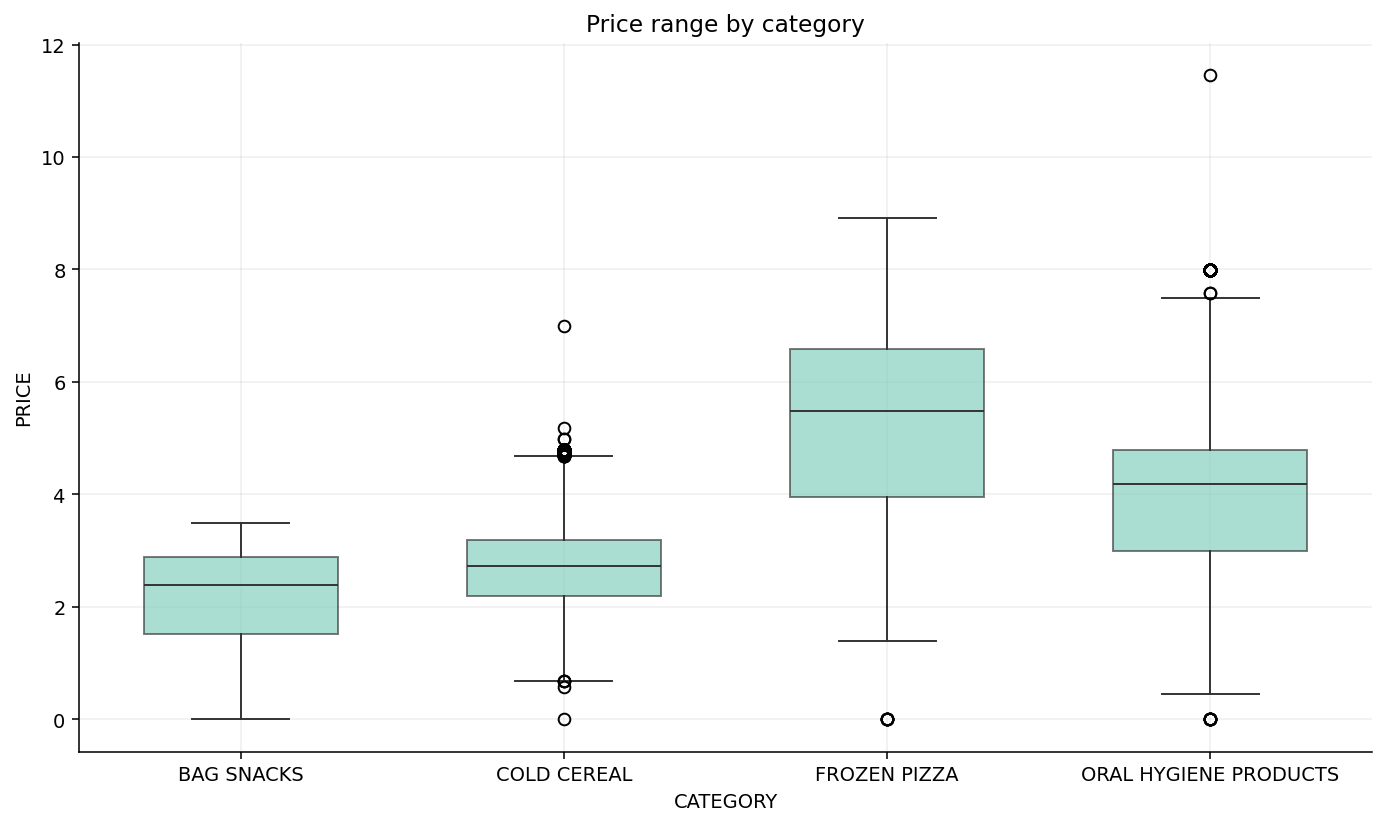

**Transaction price architecture (by category)**
- Observed transaction prices span **0.00–11.46**; occasional **0** values likely promo artifacts/returns.
- Clear laddering: **Bag Snacks** lowest; **Cold Cereal** low–mid; **Oral Hygiene** mid–high with a premium tail; **Frozen Pizza** highest.
- Dispersion: Pizza and Oral Hygiene show the widest ranges; Cereal is tighter; Snacks are compressed at the low end.
- Implication: set category-specific price bands and handle zero-price records explicitly in downstream analyses.

**Next:** Quantify **market promo dynamics** — penetration, depth, and promo revenue share.

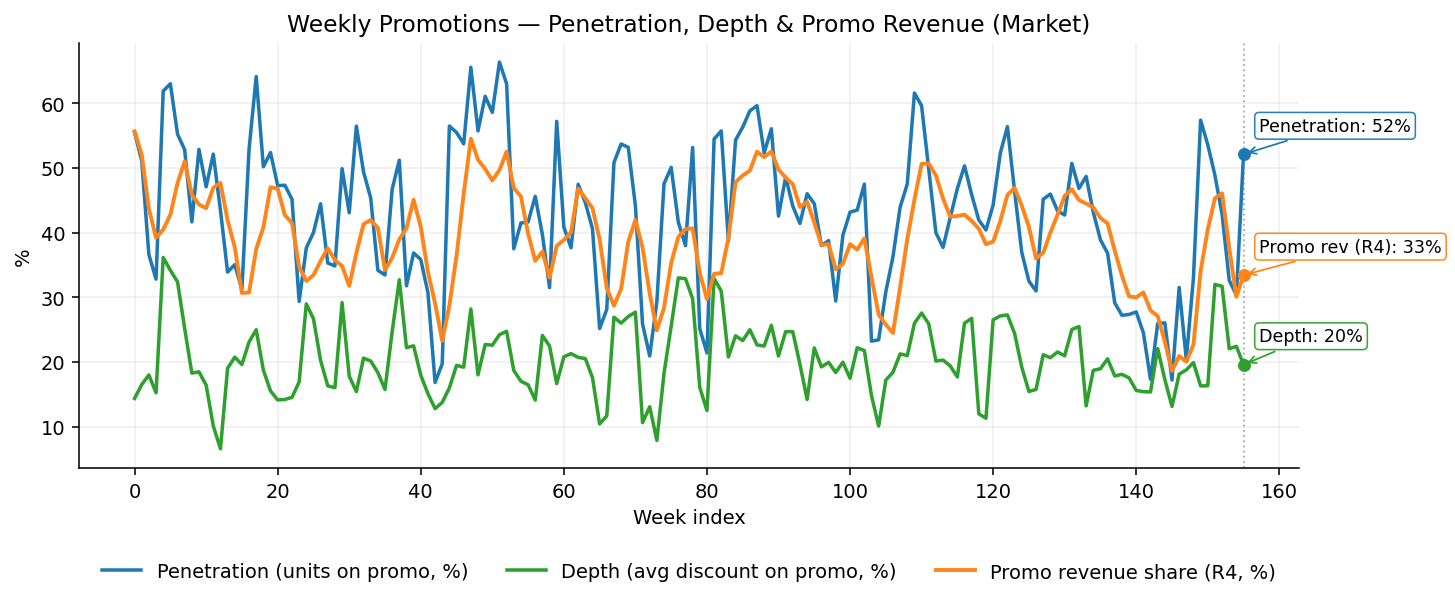

**Market promo dynamics**
- Latest penetration **52.1%**, depth **19.6%**; promo-rev (R4) **33.4%**.
- Rising penetration with flat depth → more units on lighter promos (margin-friendlier mix).
- Rising depth without unit response → wasted margin; prefer shallower TPRs with feature/display support.

**Next:** Check whether these dynamics are tier-specific or calendar-driven using a tier cut.

In [8]:
## Exploratory Analysis

### Price Landscape
# (Price boxplots)
## 2b) Price Landscape & Thresholds
df_prices = df.copy()
df_prices["CATEGORY"]   = df_prices.get("CATEGORY", "Unknown").astype(str)
df_prices["PRICE"]      = pd.to_numeric(df_prices.get("PRICE"), errors="coerce")
df_prices["BASE_PRICE"] = pd.to_numeric(df_prices.get("BASE_PRICE"), errors="coerce").fillna(df_prices["PRICE"])
df_prices["UNITS_USE"]  = pd.to_numeric(df_prices.get("UNITS_USE", df_prices.get("UNITS")), errors="coerce")

wrk = df_prices[(df_prices["BASE_PRICE"] >= 0) & (df_prices["UNITS_USE"].notna())].copy()
cat_order = sorted(wrk["CATEGORY"].dropna().unique().tolist())
wrk["CATEGORY"] = pd.Categorical(wrk["CATEGORY"], cat_order, ordered=True)

p_min = float(np.nanmin(wrk["PRICE"]))
p_max = float(np.nanmax(wrk["PRICE"]))

plt.figure(figsize=(10, 6))
data_by_cat = [wrk.loc[wrk["CATEGORY"].eq(c), "PRICE"].dropna().values for c in cat_order]
bp = plt.boxplot(data_by_cat, showfliers=True, patch_artist=True, widths=0.6)
for patch in bp['boxes']:
    patch.set_facecolor("#7fcdbb"); patch.set_alpha(0.65); patch.set_edgecolor("#333333")
for artist in bp['whiskers'] + bp['caps'] + bp['medians']:
    artist.set_color("#333333")
plt.xticks(ticks=np.arange(1, len(cat_order)+1), labels=cat_order)
plt.xlabel("CATEGORY"); plt.ylabel("PRICE"); plt.title("Price range by category")
plt.grid(axis="y", alpha=0.2); plt.tight_layout()
savefig(OUTDIR / "fig_price_boxplots_by_category.png")

takeaway(
  "Transaction price architecture (by category)",
  [
    f"Observed transaction prices span **{p_min:.2f}–{p_max:.2f}**; occasional **0** values likely promo artifacts/returns.",
    "Clear laddering: **Bag Snacks** lowest; **Cold Cereal** low–mid; **Oral Hygiene** mid–high with a premium tail; **Frozen Pizza** highest.",
    "Dispersion: Pizza and Oral Hygiene show the widest ranges; Cereal is tighter; Snacks are compressed at the low end.",
    "Implication: set category-specific price bands and handle zero-price records explicitly in downstream analyses."
  ],
  nxt="Quantify **market promo dynamics** — penetration, depth, and promo revenue share."
)

### Promotion Analysis
# (Penetration, depth)
## 3) Market Promotions — Penetration, Depth, Promo Revenue
from matplotlib.ticker import StrMethodFormatter

dfk = df.copy()
dfk["IS_PROMO"] = ((dfk.get("FEATURE", 0)==1) | (dfk.get("DISPLAY", 0)==1) | (dfk.get("TPR_ONLY", 0)==1)).astype(int)
dfk["PRICE"] = pd.to_numeric(dfk.get("PRICE"), errors="coerce")
dfk["BASE_PRICE"] = pd.to_numeric(dfk.get("BASE_PRICE", dfk["PRICE"]), errors="coerce").fillna(dfk["PRICE"])
dfk["UNITS_USE"] = pd.to_numeric(dfk.get("UNITS_USE", dfk.get("UNITS")), errors="coerce")
dfk["DISCOUNT_PCT"] = ((dfk["BASE_PRICE"] - dfk["PRICE"]) / dfk["BASE_PRICE"]).replace([np.inf,-np.inf], np.nan).clip(lower=0)

if "WEEK_END_DATE" in dfk.columns and str(dfk["WEEK_END_DATE"].dtype).startswith("datetime64"):
    dfk["_WEEK"] = dfk["WEEK_END_DATE"].dt.to_period("W").astype(str)
else:
    dfk["_WEEK"] = dfk["WEEK"].astype(str)

weekly_units = (dfk.groupby("_WEEK", dropna=False)
                  .agg(TOTAL_UNITS=("UNITS_USE","sum"),
                       PROMO_UNITS=("UNITS_USE", lambda s: s[dfk.loc[s.index, "IS_PROMO"].eq(1)].sum()))
                  .reset_index())
weekly_units["PROMO_PENETRATION_%"] = 100 * weekly_units["PROMO_UNITS"] / weekly_units["TOTAL_UNITS"]

weekly_depth = (dfk[dfk["IS_PROMO"].eq(1)]
                  .assign(UNITSxDISC=lambda x: x["UNITS_USE"] * x["DISCOUNT_PCT"])
                  .groupby("_WEEK", dropna=False)
                  .agg(PROMO_UNITS=("UNITS_USE","sum"),
                       UNITSxDISC=("UNITSxDISC","sum"))
                  .reset_index())
weekly_depth["PROMO_DEPTH_%"] = 100 * weekly_depth["UNITSxDISC"] / weekly_depth["PROMO_UNITS"]

weekly_biz = weekly_units.merge(weekly_depth[["_WEEK","PROMO_DEPTH_%"]], on="_WEEK", how="left")

if "SPEND" in dfk.columns:
    dfk["REVENUE"] = pd.to_numeric(dfk["SPEND"], errors="coerce")
else:
    dfk["REVENUE"] = dfk["PRICE"] * dfk["UNITS_USE"]
dfk["REVENUE_PROMO"] = dfk["REVENUE"] * dfk["IS_PROMO"]

weekly_rev = (dfk.groupby("_WEEK", dropna=False)
                .agg(REVENUE_TOTAL=("REVENUE","sum"),
                     REVENUE_PROMO=("REVENUE_PROMO","sum"))
                .reset_index()
                .sort_values("_WEEK"))
weekly_rev["PROMO_REV_SHARE_%"] = 100 * weekly_rev["REVENUE_PROMO"] / weekly_rev["REVENUE_TOTAL"]
weekly_rev["PROMO_REV_SHARE_%_R4"] = weekly_rev["PROMO_REV_SHARE_%"].rolling(4, min_periods=1).mean()

kpis = weekly_biz.merge(weekly_rev[["_WEEK","PROMO_REV_SHARE_%_R4"]], on="_WEEK", how="left").reset_index(drop=True)

plt.figure(figsize=(10.5, 4.4))
y1 = kpis["PROMO_PENETRATION_%"].values
y2 = kpis["PROMO_DEPTH_%"].values
y3 = kpis["PROMO_REV_SHARE_%_R4"].values

plt.plot(y1, label="Penetration (units on promo, %)",  linewidth=1.8, color=COL["pen"])
plt.plot(y2, label="Depth (avg discount on promo, %)", linewidth=1.8, color=COL["depth"])
plt.plot(y3, label="Promo revenue share (R4, %)",      linewidth=2.0, color=COL["rev"])

ax = plt.gca()
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:.0f}'))
ax.axvline(len(kpis)-1, ls=":", lw=1, color="grey", alpha=0.6)

annotate_last_point(ax, y1, "Penetration",    COL["pen"],  fmt="{:.0f}%")
annotate_last_point(ax, y2, "Depth",          COL["depth"],fmt="{:.0f}%")
annotate_last_point(ax, y3, "Promo rev (R4)", COL["rev"],  fmt="{:.0f}%")

plt.xlabel("Week index"); plt.ylabel("%")
plt.title("Weekly Promotions — Penetration, Depth & Promo Revenue (Market)")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3)
plt.grid(alpha=0.2); plt.tight_layout()
savefig(OUTDIR/"fig_market_kpis.png")

pen_latest   = float(pd.Series(y1).dropna().iloc[-1]) if len(y1) else np.nan
depth_latest = float(pd.Series(y2).dropna().iloc[-1]) if len(y2) else np.nan
rev_r4_latest= float(pd.Series(y3).dropna().iloc[-1]) if len(y3) else np.nan
takeaway(
  "Market promo dynamics",
  [
    f"Latest penetration **{pen_latest:.1f}%**, depth **{depth_latest:.1f}%**; promo-rev (R4) **{rev_r4_latest:.1f}%**.",
    "Rising penetration with flat depth → more units on lighter promos (margin-friendlier mix).",
    "Rising depth without unit response → wasted margin; prefer shallower TPRs with feature/display support."
  ],
  nxt="Check whether these dynamics are tier-specific or calendar-driven using a tier cut."
)

## 3. Store tier segmentation

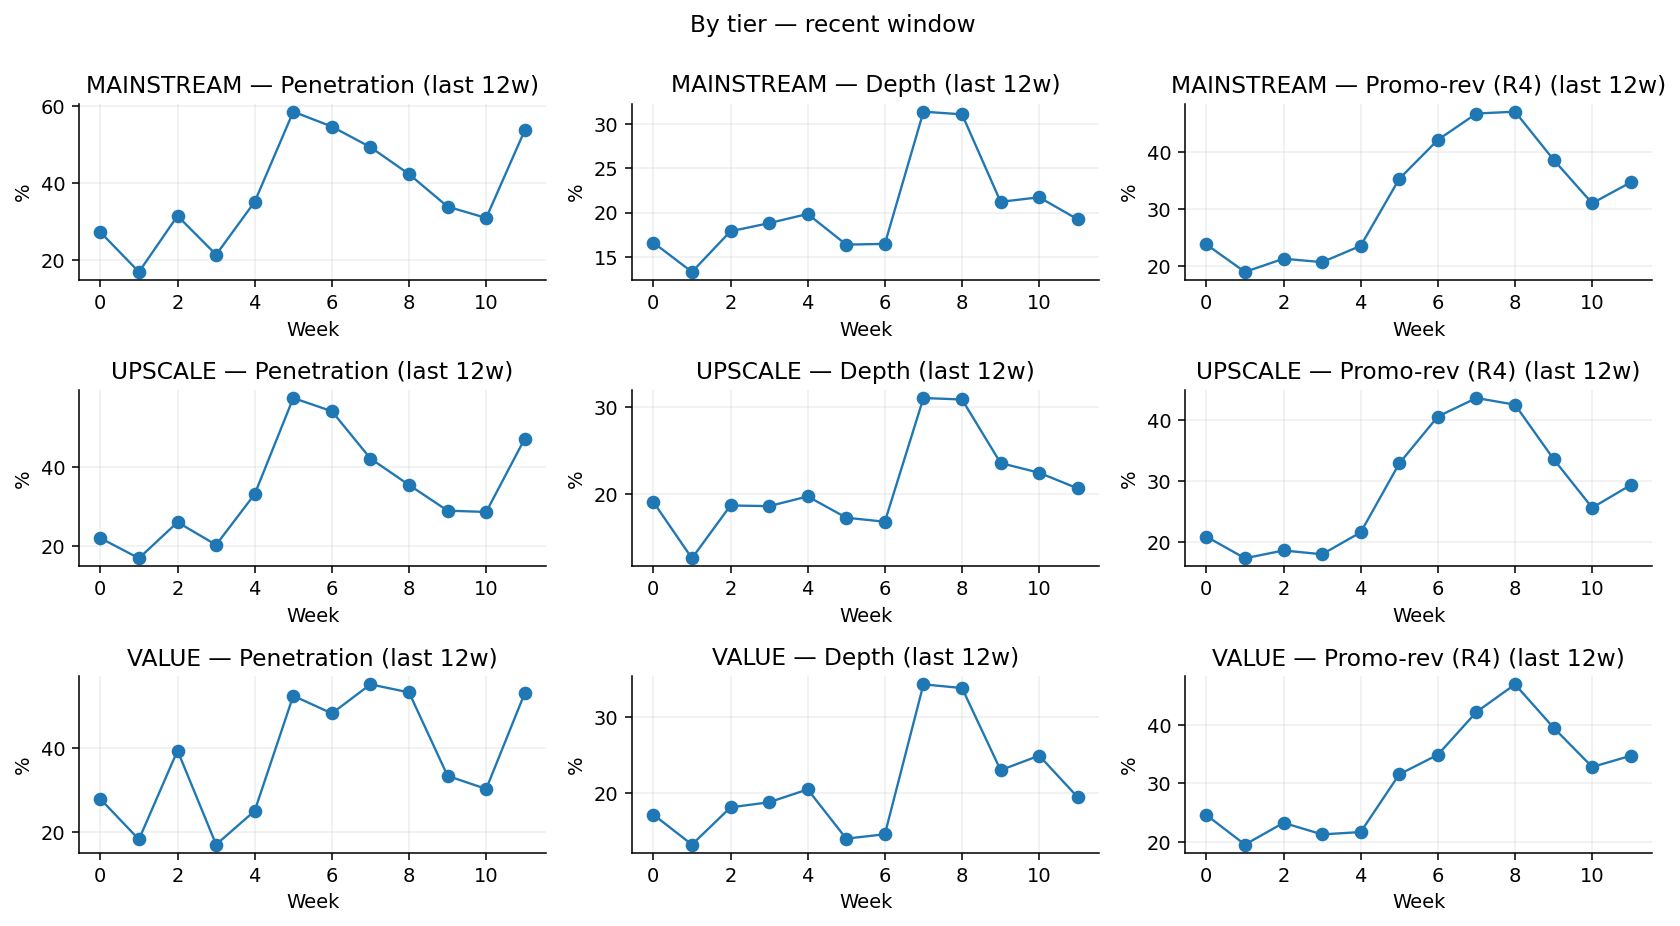

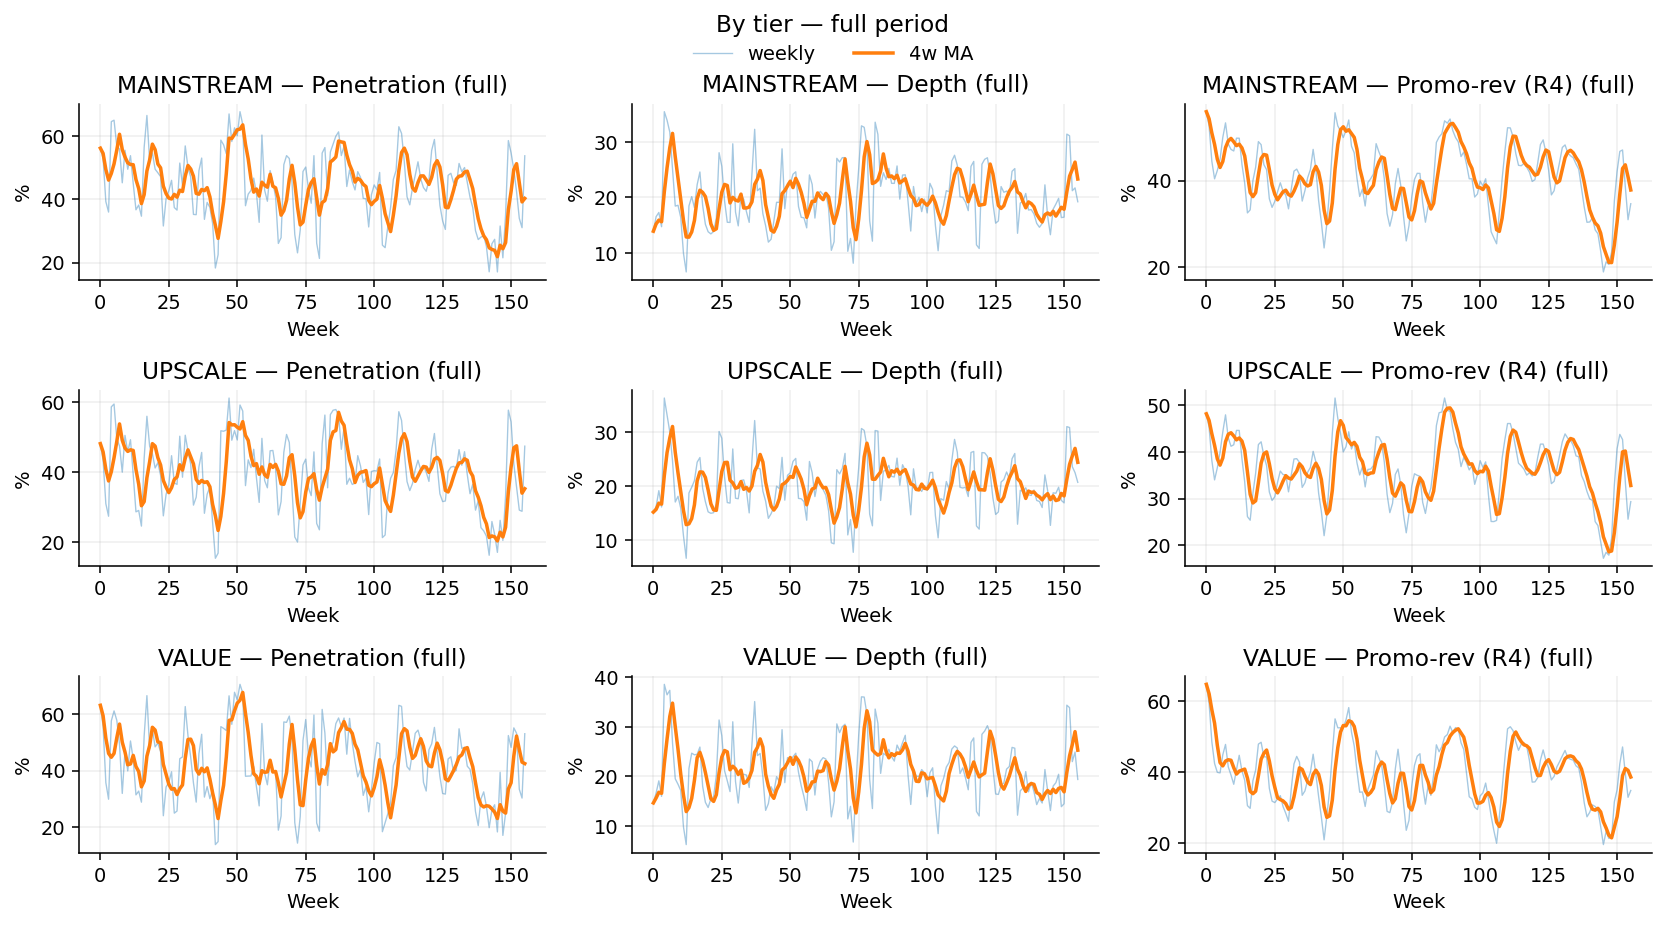

**By tier — signal check**
- Trends co-move across tiers; dynamics are calendar/supplier-driven more than tier-specific.
- Promo revenue tracks penetration more than depth → breadth of promo weeks matters.
- Tier gaps are small; category selection will dominate over tier policy.

**Next:** Estimate price elasticities (FE OLS), test heterogeneity by category/tier, and run robustness checks (rolling-origin stability, scenario in-window response).

In [10]:
### Store Tier Analysis
## 4) Store-Tier Cut — Recent + Full
from matplotlib.ticker import StrMethodFormatter

def pct_ticks_no_symbol(ax):
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:.0f}"))

def _series(df, tier, col, last_n=None):
    s = (df[df["STORE_TIER"].fillna("Unknown").eq(tier)]
           .sort_values("_WEEK")[col].astype(float)).dropna()
    return (s.tail(last_n) if (last_n and last_n > 0) else s).reset_index(drop=True)

by_tier = (dfk.groupby(["_WEEK","STORE_TIER"], dropna=False)
             .agg(TOTAL_UNITS=("UNITS_USE","sum"),
                  PROMO_UNITS=("UNITS_USE", lambda s: s[dfk.loc[s.index,"IS_PROMO"].eq(1)].sum()))
             .reset_index())
by_tier["PROMO_PENETRATION_%"] = 100 * by_tier["PROMO_UNITS"] / by_tier["TOTAL_UNITS"]

dfk["_UNITSxDISC"] = dfk["UNITS_USE"] * dfk["DISCOUNT_PCT"]
depth_tier = (dfk[dfk["IS_PROMO"].eq(1)]
                .groupby(["_WEEK","STORE_TIER"], dropna=False)
                .agg(PROMO_UNITS=("UNITS_USE","sum"),
                     UNITSxDISC=("_UNITSxDISC","sum"))
                .reset_index())
depth_tier["PROMO_DEPTH_%"] = 100 * depth_tier["UNITSxDISC"] / depth_tier["PROMO_UNITS"]

tier_biz = by_tier.merge(depth_tier[["_WEEK","STORE_TIER","PROMO_DEPTH_%"]], on=["_WEEK","STORE_TIER"], how="left")

df_rev_t = dfk.copy()
if "REVENUE" not in df_rev_t.columns:
    df_rev_t["REVENUE"] = pd.to_numeric(df_rev_t.get("SPEND", np.nan), errors="coerce")
    if df_rev_t["REVENUE"].isna().all():
        df_rev_t["REVENUE"] = (pd.to_numeric(df_rev_t.get("PRICE", np.nan), errors="coerce")
                               * pd.to_numeric(df_rev_t.get("UNITS_USE", np.nan), errors="coerce"))
df_rev_t["REVENUE_PROMO"] = df_rev_t["REVENUE"] * df_rev_t["IS_PROMO"]

tier_rev = (df_rev_t.groupby(["_WEEK","STORE_TIER"], dropna=False)
              .agg(REVENUE_TOTAL=("REVENUE","sum"),
                   REVENUE_PROMO=("REVENUE_PROMO","sum"))
              .reset_index()
              .sort_values(["STORE_TIER","_WEEK"]))
tier_rev["PROMO_REV_SHARE_%"] = 100 * tier_rev["REVENUE_PROMO"] / tier_rev["REVENUE_TOTAL"]
tier_rev["PROMO_REV_SHARE_%_R4"] = (
    tier_rev.groupby("STORE_TIER", group_keys=False)["PROMO_REV_SHARE_%"]
            .apply(lambda s: s.rolling(4, min_periods=1).mean())
)

def plot_by_tier_recent(tier_biz, tier_rev, recent_weeks=12):
    tiers = sorted(tier_biz["STORE_TIER"].fillna("Unknown").unique())
    if not recent_weeks: return
    fig, axes = plt.subplots(len(tiers), 3, figsize=(12, 2.2*len(tiers)), sharex=False)
    if len(tiers) == 1: axes = np.array([axes])
    for i, t in enumerate(tiers):
        for j, (col, ttl) in enumerate([
            ("PROMO_PENETRATION_%","Penetration"),
            ("PROMO_DEPTH_%","Depth"),
            ("PROMO_REV_SHARE_%_R4","Promo-rev (R4)")
        ]):
            s = _series(tier_biz if j < 2 else tier_rev, t, col, last_n=recent_weeks)
            ax = axes[i, j]
            ax.plot(s.values, marker="o", linewidth=1.2)
            ax.set_title(f"{t} — {ttl} (last {recent_weeks}w)")
            pct_ticks_no_symbol(ax); ax.set_ylabel("%"); ax.set_xlabel("Week"); ax.grid(alpha=0.2)
    fig.suptitle("By tier — recent window", y=0.995)
    plt.tight_layout()
    savefig(OUTDIR / "fig_tier_recent.png")

def plot_by_tier_full_single_legend(tier_biz, tier_rev, smooth_full=4):
    tiers = sorted(tier_biz["STORE_TIER"].fillna("Unknown").unique())
    fig, axes = plt.subplots(len(tiers), 3, figsize=(12, 2.2*len(tiers)), sharex=False)
    if len(tiers) == 1: axes = np.array([axes])
    fig.subplots_adjust(hspace=0.35, wspace=0.25, top=0.86)

    fig_handles, fig_labels = None, None
    panels = [
        (tier_biz, "PROMO_PENETRATION_%","Penetration"),
        (tier_biz, "PROMO_DEPTH_%","Depth"),
        (tier_rev, "PROMO_REV_SHARE_%_R4","Promo-rev (R4)")
    ]
    for i, t in enumerate(tiers):
        for j, (frame, col, ttl) in enumerate(panels):
            s_full = _series(frame, t, col, last_n=None)
            s_ma   = s_full.rolling(smooth_full, min_periods=1).mean()
            ax = axes[i, j]
            h_weekly, = ax.plot(s_full.values, linewidth=0.7, alpha=0.4, label="weekly")
            h_ma,     = ax.plot(s_ma.values,   linewidth=1.8, label=f"{smooth_full}w MA")
            if fig_handles is None:
                fig_handles = [h_weekly, h_ma]; fig_labels  = [h.get_label() for h in fig_handles]
            ax.set_title(f"{t} — {ttl} (full)")
            pct_ticks_no_symbol(ax); ax.set_ylabel("%"); ax.set_xlabel("Week"); ax.grid(alpha=0.2)

    if fig_handles:
        fig.legend(fig_handles, fig_labels, ncol=2, loc="upper center", bbox_to_anchor=(0.5, 0.98), frameon=False)

    fig.suptitle("By tier — full period", y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    savefig(OUTDIR / "fig_tier_full.png")

plot_by_tier_recent(tier_biz, tier_rev, recent_weeks=12)
plot_by_tier_full_single_legend(tier_biz, tier_rev, smooth_full=4)

takeaway(
  "By tier — signal check",
  [
    "Trends co-move across tiers; dynamics are calendar/supplier-driven more than tier-specific.",
    "Promo revenue tracks penetration more than depth → breadth of promo weeks matters.",
    "Tier gaps are small; category selection will dominate over tier policy."
  ],
  nxt="Estimate price elasticities (FE OLS), test heterogeneity by category/tier, and run robustness checks (rolling-origin stability, scenario in-window response)."
)

## 4. Price elasticity estimation using fixed effects regression

Price elasticity measures how sensitive demand is to price changes.

A fixed-effects regression model was used to control for:
- product characteristics
- store differences
- weekly time effects

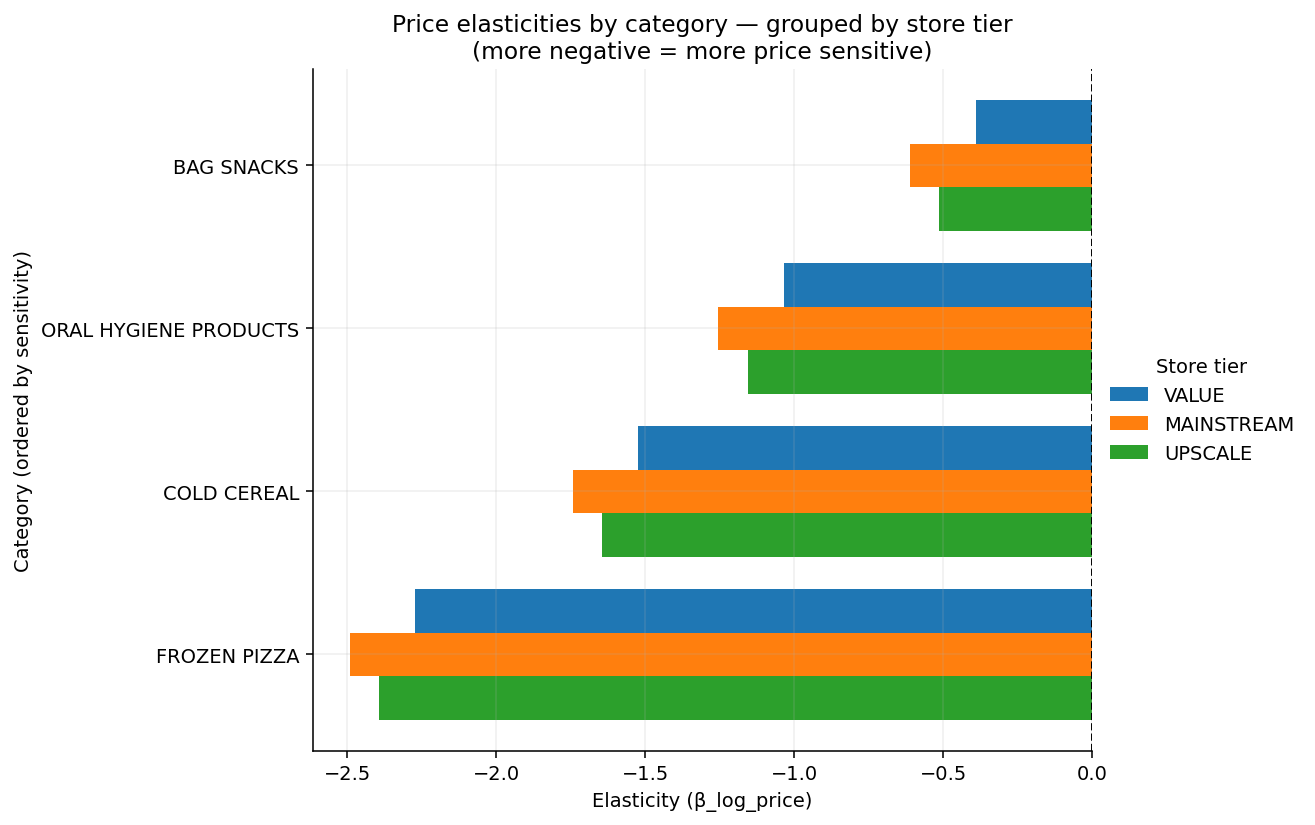

Metric,Value
K,5
beta_mean,-1.374818
beta_std,0.031675
beta_min,-1.401256
beta_max,-1.321528
cv_abs,0.02304
sign_flips,0


**Elasticities — what moves volume**
- Market FE β_log_price ≈ **-1.38**; off-promo FE β ≈ **-1.34** (directional; UPC/Store/Week FE with promo controls).
- Rolling-origin stability: **no sign flips**, tight range, **CV ≈ 2–3%** → β is temporally stable.
- Own-price response is **category-led** with modest tier variation. Use β to rank sensitivity; rely on scenario curves for **in-window** decisions.

**Next:** Train a leak-safe XGB forecast; benchmark; then simulate ΔPrice → ΔUnits/ΔMargin.

In [13]:
## Price Elasticity Estimation
## 5) Price Elasticities — FE OLS + Heterogeneity + Stability
import statsmodels.formula.api as smf

dfm = df.copy()
dfm = dfm[(dfm["PRICE"]>0) & (dfm["UNITS_USE"]>0)].copy()
if "WEEK_END_DATE" in dfm.columns and str(dfm["WEEK_END_DATE"].dtype).startswith("datetime64"):
    dfm["WEEK"] = dfm["WEEK_END_DATE"].dt.to_period("W").astype(str)

dfm["log_units"] = np.log(dfm["UNITS_USE"])
dfm["log_price"] = np.log(dfm["PRICE"])

# Baseline FE OLS with promo controls and fixed effects
base_formula = "log_units ~ log_price + FEATURE + DISPLAY + TPR_ONLY + C(UPC) + C(STORE_NUM) + C(WEEK)"
mod_base = smf.ols(base_formula, data=dfm).fit(cov_type="cluster", cov_kwds={"groups": dfm["STORE_NUM"]})
beta_market = float(mod_base.params.get("log_price", np.nan))

# Off-promo cut (directional)
off_e = np.nan
if all(c in dfm.columns for c in ["FEATURE","DISPLAY","TPR_ONLY"]):
    df_off = dfm[(dfm["FEATURE"]==0) & (dfm["DISPLAY"]==0) & (dfm["TPR_ONLY"]==0)]
    if len(df_off) >= 100:
        mod_off = smf.ols(base_formula, data=df_off).fit(cov_type="cluster", cov_kwds={"groups": df_off["STORE_NUM"]})
        off_e = float(mod_off.params.get("log_price", np.nan))

# Heterogeneity via interactions (Category / Tier)
def has_real_levels(s, min_levels=2):
    return (s is not None) and (s.notna().sum()>0) and (s.dropna().nunique()>=min_levels)

cat_ok  = ("CATEGORY"   in dfm.columns) and has_real_levels(dfm["CATEGORY"])
tier_ok = ("STORE_TIER" in dfm.columns) and has_real_levels(dfm["STORE_TIER"])

base_terms = ["log_price","FEATURE","DISPLAY","TPR_ONLY","C(UPC)","C(STORE_NUM)","C(WEEK)"]
main_terms, inter_terms = [], []
if cat_ok:  main_terms.append("C(CATEGORY)");   inter_terms.append("log_price:C(CATEGORY)")
if tier_ok: main_terms.append("C(STORE_TIER)"); inter_terms.append("log_price:C(STORE_TIER)")

mod_het = mod_base
if inter_terms:
    het_formula = "log_units ~ " + " + ".join(base_terms + main_terms + inter_terms)
    needed = ["log_units","log_price","FEATURE","DISPLAY","TPR_ONLY","UPC","STORE_NUM","WEEK"]
    if cat_ok:  needed.append("CATEGORY")
    if tier_ok: needed.append("STORE_TIER")
    dfh = dfm.dropna(subset=[c for c in needed if c in dfm.columns]).copy()
    mod_het = smf.ols(het_formula, data=dfh).fit(cov_type="cluster", cov_kwds={"groups": dfh["STORE_NUM"]})
else:
    dfh = dfm.copy()

# Build a point-estimate table for elasticities per segment
def seg_beta(model, c=None, t=None):
    P = model.params
    b = P.get("log_price", np.nan)
    if c is not None and f"log_price:C(CATEGORY)[T.{c}]" in P.index:
        b += P[f"log_price:C(CATEGORY)[T.{c}]"]
    if t is not None and f"log_price:C(STORE_TIER)[T.{t}]" in P.index:
        b += P[f"log_price:C(STORE_TIER)[T.{t}]"]
    return float(b)

rows=[]
cats  = sorted(dfh["CATEGORY"].dropna().unique()) if cat_ok else []
tiers = sorted(dfh["STORE_TIER"].dropna().unique()) if tier_ok else []

if cats and tiers:
    for c in cats:
        for t in tiers:
            rows.append({"CATEGORY": c, "STORE_TIER": t, "ELASTICITY": seg_beta(mod_het, c, t)})
elif cats:
    for c in cats:
        rows.append({"CATEGORY": c, "STORE_TIER": np.nan, "ELASTICITY": seg_beta(mod_het, c, None)})
elif tiers:
    for t in tiers:
        rows.append({"CATEGORY": np.nan, "STORE_TIER": t, "ELASTICITY": seg_beta(mod_het, None, t)})
else:
    rows.append({"CATEGORY": np.nan, "STORE_TIER": np.nan, "ELASTICITY": float(mod_base.params.get("log_price", np.nan))})

seg_elast = pd.DataFrame(rows)
seg_elast.to_csv(OUTDIR/"segment_elasticities.csv", index=False)  # no CIs

# Visual: Category × Elasticity (grouped by tier)
need = seg_elast.dropna(subset=["CATEGORY"]).copy()
if "STORE_TIER" not in need.columns: need["STORE_TIER"] = "ALL"
need = need.groupby(["CATEGORY","STORE_TIER"], as_index=False)["ELASTICITY"].mean()

cat_order = (need.groupby("CATEGORY")["ELASTICITY"].mean().sort_values(ascending=True).index.tolist())
need["CATEGORY"] = pd.Categorical(need["CATEGORY"], cat_order, ordered=True)
tier_order = [t for t in ["VALUE","MAINSTREAM","UPSCALE","ALL"] if t in need["STORE_TIER"].unique()]
need["STORE_TIER"] = pd.Categorical(need["STORE_TIER"], categories=tier_order, ordered=True)
need = need.sort_values(["CATEGORY","STORE_TIER"])

n_cat  = len(cat_order)
n_tier = len(tier_order)
group_h = 0.8
bar_h   = group_h / max(1, n_tier)
y_idx   = np.arange(n_cat)
center_shift = ((n_tier - 1)/2.0 - np.arange(n_tier)) * bar_h

h = max(6, 0.45 * n_cat)
plt.figure(figsize=(9.5, h))
plt.axvline(0, lw=1, ls="--", color="black")
for j, t in enumerate(tier_order):
    d = need[need["STORE_TIER"] == t]
    x = d.set_index("CATEGORY").reindex(cat_order)["ELASTICITY"].values
    offsets = y_idx + center_shift[j]
    plt.barh(offsets, x, height=bar_h, label=t)
plt.yticks(y_idx, cat_order)
plt.xlabel("Elasticity (β_log_price)"); plt.ylabel("Category (ordered by sensitivity)")
plt.title("Price elasticities by category — grouped by store tier\n(more negative = more price sensitive)")
plt.legend(title="Store tier", bbox_to_anchor=(1.0, 0.5), loc="center left")
plt.tight_layout(); savefig(OUTDIR/"fig_elasticities.png")

# Robustness: rolling-origin stability of β_log_price
def rolling_origin_elasticity(dfm, K=5, cluster_key="STORE_NUM"):
    weeks = pd.Series(dfm["WEEK"].unique()).sort_values().tolist()
    cut_idx = np.linspace(int(len(weeks)*0.5), len(weeks)-1, K, dtype=int)
    rows=[]
    for k, ci in enumerate(cut_idx, start=1):
        train_weeks = weeks[:ci]
        dtr = dfm[dfm["WEEK"].isin(train_weeks)]
        resk = smf.ols(base_formula, data=dtr).fit(cov_type="cluster", cov_kwds={"groups": dtr[cluster_key]})
        rows.append({"fold":k, "beta": float(resk.params.get("log_price", np.nan))})
    r = pd.DataFrame(rows)
    return pd.Series({
        "K": len(r),
        "beta_mean": r["beta"].mean(),
        "beta_std":  r["beta"].std(ddof=1),
        "beta_min":  r["beta"].min(),
        "beta_max":  r["beta"].max(),
        "cv_abs":    (r["beta"].std(ddof=1) / (abs(r["beta"].mean())+1e-9)),
        "sign_flips": int(np.sign(r["beta"]).nunique() > 1)
    })

stab = rolling_origin_elasticity(dfm, K=5)

# tidy + ordered rows
order = ["K","beta_mean","beta_std","beta_min","beta_max","cv_abs","sign_flips"]
stab_df = (
    stab.to_frame(name="Value")
        .rename_axis("Metric")
        .reset_index()
        .assign(Metric=lambda d: pd.Categorical(d["Metric"], categories=order, ordered=True))
        .sort_values("Metric")
        .reset_index(drop=True)
)

# styled display
display(
    stab_df.style
        .hide(axis="index")
        .set_caption("Rolling-origin elasticity stability (K=5)")
        .format({
            "Value": lambda v: (
                f"{int(v):,}" if pd.notna(v) and float(v).is_integer() else
                f"{v:,.6f}".rstrip("0").rstrip(".")
            )
        })
        .set_properties(subset=["Metric"], **{"font-weight":"600"})
)

stab_df.to_csv(OUTDIR / "elasticity_stability_rolling.csv", index=False)

takeaway(
  "Elasticities — what moves volume",
  [
    f"Market FE β_log_price ≈ **{beta_market:.2f}**; off-promo FE β ≈ **{off_e:.2f}** (directional; UPC/Store/Week FE with promo controls).",
    "Rolling-origin stability: **no sign flips**, tight range, **CV ≈ 2–3%** → β is temporally stable.",
    "Own-price response is **category-led** with modest tier variation. Use β to rank sensitivity; rely on scenario curves for **in-window** decisions."
  ],
  nxt="Train a leak-safe XGB forecast; benchmark; then simulate ΔPrice → ΔUnits/ΔMargin."
)

## 5. Demand forecasting using XGBoost

,MAE,RMSE,MAPE_%,WAPE_%,SMAPE_%,R2_test_units,R2_test_log1p,N_test
0,5.314,10.793,54.606,28.421,37.451,0.843,0.825,121622


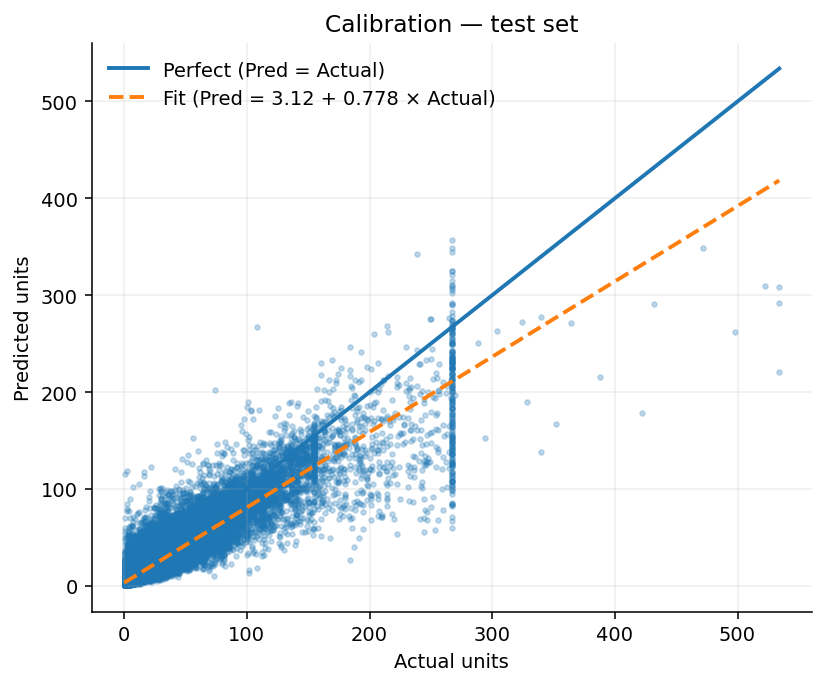

**Forecasting (XGB) — holdout & calibration**
- Holdout **WAPE ≈ 28.4%**; **R² (units) ≈ 0.84**.
- Calibration is close to the 45° line with mild bias at extremes — adequate for scenario analysis.

**Next:** Benchmark against naïve baselines on the same split.

,Model,MAE,RMSE,WAPE_%,SMAPE_%,R2_units,N
0,Naïve — Last week,7.79,18.77,41.69%,48.54%,0.525,"121,605"
1,Naïve — MA4 (t-1),8.03,19.02,42.92%,46.41%,0.512,"121,605"
2,Seasonal-naïve (t-52),11.00,24.88,57.88%,58.98%,0.177,"119,117"
3,XGB (log1p target),5.31,10.79,28.42%,37.45%,0.843,"121,622"


**Holdout benchmarks — naïve vs XGB**
- XGB beats naïve baselines on **WAPE/RMSE** with solid **R²**.
- MA4 is a reasonable fallback for sparse SKUs; seasonal-naïve helps only with strong seasonality.

**Next:** Set up the scenario simulator (uses the fitted XGB) and build in-window curves.

In [15]:
## Demand Forecasting with XGBoost
## 6a) Forecasting (XGB) — Holdout + Calibration
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# Leak-safe model frame
dfX = df.copy()
if "WEEK_END_DATE" in dfX.columns and str(dfX["WEEK_END_DATE"].dtype).startswith("datetime64"):
    dfX = dfX.sort_values(["UPC","STORE_NUM","WEEK_END_DATE"])
    dfX["YEAR"] = dfX["WEEK_END_DATE"].dt.year
    dfX["WEEK_NUM"] = dfX["WEEK_END_DATE"].dt.isocalendar().week.astype(int)
    split_series = pd.to_datetime(dfX["WEEK_END_DATE"], errors="coerce")
else:
    dfX = dfX.sort_values(["UPC","STORE_NUM","WEEK"])
    dfX["YEAR"] = 0
    dfX["WEEK_NUM"] = pd.to_numeric(dfX.get("WEEK"), errors="coerce").fillna(0).astype(int)
    split_series = pd.to_numeric(dfX.get("WEEK"), errors="coerce")

two_pi = 2*np.pi
dfX["SEASON_SIN"] = np.sin(two_pi*dfX["WEEK_NUM"]/52.0)
dfX["SEASON_COS"] = np.cos(two_pi*dfX["WEEK_NUM"]/52.0)

for c in ["PRICE","BASE_PRICE","UNITS_USE","DISCOUNT"]:
    if c not in dfX.columns: dfX[c] = np.nan
dfX["BASE_PRICE"]   = dfX["BASE_PRICE"].fillna(dfX["PRICE"])
dfX["DISCOUNT"]     = dfX["DISCOUNT"].fillna((dfX["BASE_PRICE"] - dfX["PRICE"]).clip(lower=0))
dfX["DISCOUNT_PCT"] = (dfX["DISCOUNT"] / dfX["BASE_PRICE"]).replace([np.inf,-np.inf], np.nan)

grp = dfX.groupby(["UPC","STORE_NUM"], sort=False)
dfX["UNITS_L1"]     = grp["UNITS_USE"].shift(1)
dfX["UNITS_L2"]     = grp["UNITS_USE"].shift(2)
dfX["PRICE_L1"]     = grp["PRICE"].shift(1)
dfX["UNITS_MA4"]    = grp["UNITS_USE"].transform(lambda s: s.shift(1).rolling(4, min_periods=1).mean())
dfX["UNITS_MA8"]    = grp["UNITS_USE"].transform(lambda s: s.shift(1).rolling(8, min_periods=1).mean())
dfX["DISCOUNT_MA4"] = grp["DISCOUNT"].transform(lambda s: s.shift(1).rolling(4, min_periods=1).mean())

if "STORE_SIZE" in dfX.columns:
    dfX["STORE_SIZE"] = pd.to_numeric(dfX["STORE_SIZE"], errors="coerce")

for c in ["PROMO_STATE","FEATURE","DISPLAY","TPR_ONLY","CATEGORY","SUB_CATEGORY","STORE_TIER","STATE"]:
    if c not in dfX.columns:
        dfX[c] = np.nan if c in ["CATEGORY","SUB_CATEGORY","STORE_TIER","STATE","PROMO_STATE"] else 0
    if c in ["FEATURE","DISPLAY","TPR_ONLY"]:
        dfX[c] = pd.to_numeric(dfX[c], errors="coerce").fillna(0).astype(int)

dfX["UNITS_USE"] = pd.to_numeric(dfX["UNITS_USE"], errors="coerce")
for c in ["PRICE","BASE_PRICE","PRICE_L1","UNITS_L1","UNITS_L2","UNITS_MA4","UNITS_MA8","DISCOUNT_PCT","DISCOUNT_MA4"]:
    if c in dfX.columns and dfX[c].isna().any():
        if c in ["PRICE_L1","UNITS_L1","UNITS_L2","UNITS_MA4","UNITS_MA8","DISCOUNT_MA4"]:
            dfX[c] = dfX[c].fillna(0)

cat_feats = [c for c in ["PROMO_STATE","FEATURE","DISPLAY","TPR_ONLY","CATEGORY","SUB_CATEGORY","STORE_TIER","STATE"] if c in dfX.columns]
dfX["LOG_PRICE"]    = np.log(np.clip(dfX["PRICE"], 1e-6, None))
dfX["PRICE_CHG_L1"] = (dfX["PRICE"]/dfX["PRICE_L1"] - 1).replace([np.inf,-np.inf], 0).fillna(0).clip(-0.8, 0.8)
num_feats = [c for c in [
    "PRICE","BASE_PRICE","DISCOUNT","DISCOUNT_PCT","PRICE_L1","DISCOUNT_MA4",
    "UNITS_L1","UNITS_L2","UNITS_MA4","UNITS_MA8",
    "STORE_SIZE","WEEK_NUM","YEAR","SEASON_SIN","SEASON_COS","LOG_PRICE","PRICE_CHG_L1"
] if c in dfX.columns and c not in set(cat_feats)]

X = dfX[cat_feats + num_feats].copy()
y = dfX["UNITS_USE"].astype(float)
y_log = np.log1p(y)

# Time split
weeks_sorted = np.sort(pd.Series(pd.to_datetime(split_series, errors="coerce")).dropna().unique())
t_cut = weeks_sorted[120] if len(weeks_sorted) > 120 else weeks_sorted[int(len(weeks_sorted)*0.8)]
train_mask = (pd.to_datetime(split_series, errors="coerce") < t_cut)
train_mask = pd.Series(train_mask, index=dfX.index).reindex(X.index, fill_value=False).to_numpy()
test_mask  = ~train_mask

# Pipeline & model
ohe_kwargs = dict(handle_unknown="ignore")
if "sparse_output" in inspect.signature(OneHotEncoder).parameters: ohe_kwargs["sparse_output"] = True
else: ohe_kwargs["sparse"] = True

pre = ColumnTransformer([
    ("cat", OneHotEncoder(**ohe_kwargs), cat_feats),
    ("num", "passthrough",               num_feats)
])

xgb_params = dict(
    objective="reg:squarederror", eval_metric="rmse",
    n_estimators=1200, max_depth=6, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.6, min_child_weight=8,
    reg_alpha=1.0, reg_lambda=3.0, random_state=42, n_jobs=-1
)

pipe = Pipeline([("prep", pre), ("mdl", XGBRegressor(**xgb_params))])
sample_weight_train = y.iloc[train_mask].clip(1.0) ** 0.5
pipe.fit(X.iloc[train_mask], y_log.iloc[train_mask], mdl__sample_weight=sample_weight_train)

# Holdout predictions & metrics
pred    = np.maximum(np.expm1(pipe.predict(X.iloc[test_mask])), 0).astype(float)
y_true  = y.iloc[test_mask].to_numpy().astype(float)

finite = np.isfinite(y_true) & np.isfinite(pred)
finite_log = finite & (y_true >= 0) & (pred >= 0)

from sklearn.metrics import r2_score
r2_units = (r2_score(y_true[finite], pred[finite]) if finite.sum() > 1 and np.var(y_true[finite]) > 0 else np.nan)
r2_log1p = (r2_score(np.log1p(y_true[finite_log]), np.log1p(pred[finite_log]))
            if finite_log.sum() > 1 and np.var(np.log1p(y_true[finite_log])) > 0 else np.nan)

metrics_df = pd.DataFrame([{
    "MAE": float(mean_absolute_error(y_true[finite], pred[finite])) if finite.any() else np.nan,
    "RMSE": float(np.sqrt(mean_squared_error(y_true[finite], pred[finite]))) if finite.any() else np.nan,
    "MAPE_%": float((np.abs((y_true[finite] - pred[finite]) / np.maximum(1e-6, y_true[finite]))).mean() * 100) if finite.any() else np.nan,
    "WAPE_%": wape(y_true[finite], pred[finite]) * 100 if finite.any() else np.nan,
    "SMAPE_%": smape(y_true[finite], pred[finite]) * 100 if finite.any() else np.nan,
    "R2_test_units": r2_units,
    "R2_test_log1p": r2_log1p,
    "N_test": int(finite.sum())
}])

display(metrics_df.round(3))
metrics_df.to_csv(OUTDIR/"metrics_test.csv", index=False)

# Calibration plot
m  = np.isfinite(y_true) & np.isfinite(pred)
lr = LinearRegression().fit(y_true[m].reshape(-1,1), pred[m])
a, b   = float(lr.intercept_), float(lr.coef_[0])
xx_max = float(np.nanmax([y_true[m].max(), pred[m].max()]))
xx     = np.linspace(0, xx_max, 200)

plt.figure(figsize=(6.0,5.0))
plt.scatter(y_true[m], pred[m], s=6, alpha=0.25)
plt.plot([0, xx_max], [0, xx_max], linewidth=2, label="Perfect (Pred = Actual)")
plt.plot(xx, a + b*xx, linestyle="--", linewidth=2, label=f"Fit (Pred = {a:.2f} + {b:.3f} × Actual)")
plt.xlabel("Actual units"); plt.ylabel("Predicted units")
plt.title("Calibration — test set"); plt.legend(loc="upper left"); plt.tight_layout()
savefig(OUTDIR/"fig_calibration.png")

takeaway(
  "Forecasting (XGB) — holdout & calibration",
  [
    f"Holdout **WAPE ≈ {metrics_df['WAPE_%'].iloc[0]:.1f}%**; **R² (units) ≈ {metrics_df['R2_test_units'].iloc[0]:.2f}**.",
    "Calibration is close to the 45° line with mild bias at extremes — adequate for scenario analysis."
  ],
  nxt="Benchmark against naïve baselines on the same split."
)

## 6b) Naïve baselines
ws = np.sort(pd.Series(pd.to_datetime(split_series, errors="coerce")).dropna().unique())
t_cut = ws[120] if len(ws) > 120 else ws[int(len(ws)*0.8)]
time_for_split = pd.to_datetime(split_series, errors="coerce")
train_mask_b = (time_for_split < t_cut); test_mask_b  = ~train_mask_b

dfb = df.copy()
dfb["UNITS_USE"] = pd.to_numeric(dfb.get("UNITS_USE", dfb.get("UNITS")), errors="coerce")
sort_cols = ["UPC","STORE_NUM", "WEEK_END_DATE" if "WEEK_END_DATE" in dfb.columns and str(dfb["WEEK_END_DATE"].dtype).startswith("datetime64") else "WEEK"]
dfb = dfb.sort_values(sort_cols)
g = dfb.groupby(["UPC","STORE_NUM"], sort=False)

dfb["PRED_LW"]     = g["UNITS_USE"].shift(1)
ma4 = g["UNITS_USE"].rolling(4, min_periods=1).mean().reset_index(level=[0,1], drop=True)
dfb["PRED_MA4"]    = g.apply(lambda s: ma4.loc[s.index]).reset_index(level=[0,1], drop=True)
dfb["PRED_MA4"]    = g["PRED_MA4"].shift(1)
dfb["PRED_SNAIVE"] = g["UNITS_USE"].shift(52)

te = dfb.loc[test_mask_b].copy()

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
def _eval_model(name, y_true, yhat):
    m = np.isfinite(y_true) & np.isfinite(yhat)
    if m.sum()==0 or np.var(y_true[m])==0:
        return {"Model": name, "MAE": np.nan, "RMSE": np.nan, "WAPE_%": np.nan, "SMAPE_%": np.nan, "R2_units": np.nan, "N": int(m.sum())}
    return {
        "Model": name,
        "MAE": float(mean_absolute_error(y_true[m], yhat[m])),
        "RMSE": float(np.sqrt(mean_squared_error(y_true[m], yhat[m]))),
        "WAPE_%": wape(y_true[m], yhat[m]) * 100,
        "SMAPE_%": smape(y_true[m], yhat[m]) * 100,
        "R2_units": float(r2_score(y_true[m], yhat[m])),
        "N": int(m.sum())
    }

names = {
    "lw":     "Naïve — Last week",
    "ma4":    "Naïve — MA4 (t-1)",
    "snaive": "Seasonal-naïve (t-52)",
    "xgb":    "XGB (log1p target)"
}

bench = []
bench.append(_eval_model(names["lw"],     te["UNITS_USE"].to_numpy(), te["PRED_LW"].to_numpy()))
bench.append(_eval_model(names["ma4"],    te["UNITS_USE"].to_numpy(), te["PRED_MA4"].to_numpy()))
bench.append(_eval_model(names["snaive"], te["UNITS_USE"].to_numpy(), te["PRED_SNAIVE"].to_numpy()))
bench.append(_eval_model(names["xgb"],    y_true,                      pred))

bench_df = pd.DataFrame(bench, columns=["Model","MAE","RMSE","WAPE_%","SMAPE_%","R2_units","N"]).round(3)
bench_df.to_csv(OUTDIR/"benchmarks_holdout.csv", index=False)

def _highlight_xgb_row(row: pd.Series):
    if "XGB" in str(row.get("Model", "")):
        return ["background-color:#e8f5e9;"] * len(row)
    return [""] * len(row)

styled = (
    bench_df.style
    .apply(_highlight_xgb_row, axis=1)
    .set_properties(subset=["Model"], **{"font-weight": "600"})
    .format({
        "MAE": "{:.2f}",
        "RMSE": "{:.2f}",
        "WAPE_%": "{:.2f}%",
        "SMAPE_%": "{:.2f}%",
        "R2_units": "{:.3f}",
        "N": "{:,.0f}",
    })
)
display(styled)

takeaway(
  "Holdout benchmarks — naïve vs XGB",
  [
    "XGB beats naïve baselines on **WAPE/RMSE** with solid **R²**.",
    "MA4 is a reasonable fallback for sparse SKUs; seasonal-naïve helps only with strong seasonality."
  ],
  nxt="Set up the scenario simulator (uses the fitted XGB) and build in-window curves."
)

## 6. Explainability analysis with SHAP

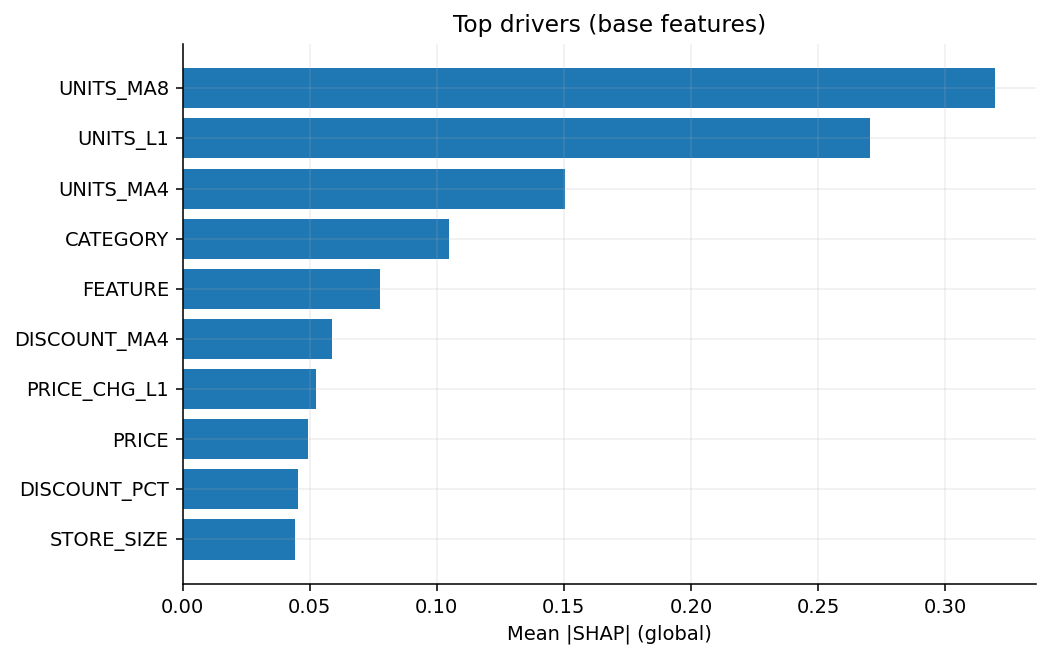

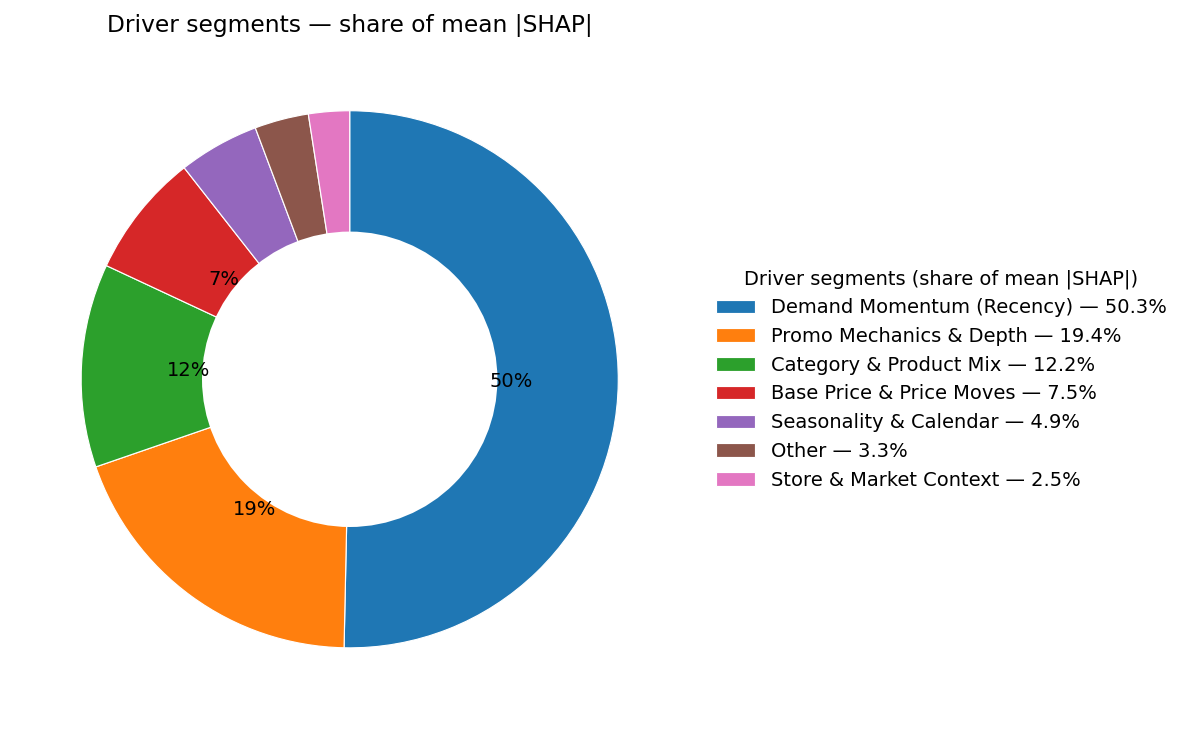

✅ SHAP artifacts saved.


,DIMENSION,SEGMENT,price_score,promo_score,RECOMMENDATION
4,STORE_TIER,VALUE,3.326608,0.795650,Shallow TPR + strong features
6,STORE_TIER,MAINSTREAM,-2.500105,0.326886,Balanced: moderate price + occasional promos
5,STORE_TIER,UPSCALE,-0.826509,-1.122536,Balanced: moderate price + occasional promos
3,CATEGORY,FROZEN PIZZA,-4.068334,1.213141,Lead with display/feature; reduce TPR-only
0,CATEGORY,COLD CEREAL,3.002126,0.420126,Shallow TPR + strong features
2,CATEGORY,ORAL HYGIENE PRODUCTS,-0.125491,-0.721767,Balanced: moderate price + occasional promos
1,CATEGORY,BAG SNACKS,1.191700,-0.911501,Sharpen base; lighter promos


**Explainability and Playbook**
- Model attention is concentrated in **Demand momentum** (**50%**) and **Promo mechanics** (**19%**).
- **Category/product mix** (**12%**) means tactics must vary by aisle; the playbook targets those differences.
- **Base price moves** (**7%**) are secondary overall → use price changes where elasticity is proven.
- **Store context** and **Seasonality** (**2%**, **5%**) are fine-tuning levers.
- Playbook flags **price-led vs promo-led** segments with concise tactics per category/tier.

**Next:** Use the fitted model to simulate ΔPrice → ΔUnits/ΔMargin; plot curves and produce a decision table.

In [17]:
## Model Explainability (SHAP)
## 7) Explainability (SHAP) — Top Drivers → Segments → Playbook
import scipy.sparse as sp

SHAPDIR = OUTDIR / "shap"; SHAPDIR.mkdir(parents=True, exist_ok=True)
ANALYSIS = OUTDIR / "analysis"; ANALYSIS.mkdir(parents=True, exist_ok=True)

shap_available = True
try:
    import shap
except Exception as e:
    shap_available = False
    print("ℹ️ SHAP not available:", e)

if shap_available:
    try:
        # Prepare encoded feature names
        ohe = pipe.named_steps["prep"].named_transformers_["cat"]
        enc_names = np.r_[ohe.get_feature_names_out(cat_feats), np.array(num_feats)]

        # Subsample test rows for SHAP
        rng = np.random.RandomState(42)
        test_idx_all = np.flatnonzero(test_mask)
        n = int(min(15000, len(test_idx_all))); assert n > 0, "No test rows for SHAP."
        sub_idx = np.sort(rng.choice(test_idx_all, size=n, replace=False))

        X_sub = X.iloc[sub_idx]
        X_sub_enc = pipe.named_steps["prep"].transform(X_sub)
        if sp.issparse(X_sub_enc): X_sub_enc = X_sub_enc.tocsr()

        try: shap.config.add(**{"data_transform":"identity"})
        except Exception: pass
        explainer   = shap.TreeExplainer(pipe.named_steps["mdl"])
        shap_values = explainer.shap_values(X_sub_enc)
        if sp.issparse(shap_values): shap_values = shap_values.toarray()
        np.save(SHAPDIR/"shap_values.npy", shap_values)

        # Collapse OHE dummies → base feature names
        cat_basenames = np.concatenate(
            [np.repeat(base, len(cats)) for base, cats in zip(ohe.feature_names_in_, ohe.categories_)]
        )
        base_names = np.r_[cat_basenames, np.array(num_feats)]
        p = X_sub_enc.shape[1]
        if len(base_names) != p:
            base_names = np.array([f"base_{i}" for i in range(p)])  # fallback

        mean_abs = np.mean(np.abs(shap_values), axis=0)
        imp_base = (pd.DataFrame({"feature": base_names, "mean_abs_shap": mean_abs})
                      .groupby("feature", as_index=False)["mean_abs_shap"].sum()
                      .sort_values("mean_abs_shap", ascending=False)
                      .reset_index(drop=True))
        imp_base.to_csv(SHAPDIR/"importance_base.csv", index=False)

        # 7a) Top 10 base features (barh)
        def _shorten(s, k=32):
            s = str(s)
            return s if len(s) <= k else s[:k-1] + "…"
        top10 = imp_base.head(10).copy()
        top10["feature_short"] = top10["feature"].map(_shorten)

        plt.figure(figsize=(7.6, 4.8))
        plt.barh(top10["feature_short"][::-1], top10["mean_abs_shap"][::-1])
        plt.xlabel("Mean |SHAP| (global)")
        plt.title("Top drivers (base features)")
        plt.tight_layout(); savefig(OUTDIR/"fig_shap_top10.png")

        # 7b) Driver segments (donut pie)
        SEG_RULES = [
            ("Demand Momentum (Recency)", ["units_l1","units_l2","units_ma","lag","recency"]),
            ("Promo Mechanics & Depth",   ["feature","display","tpr_only","promo_state","discount_pct","discount_ma","discount"]),
            ("Category & Product Mix",    ["category","sub_category","product","manufacturer","brand","size"]),
            ("Base Price & Price Moves",  ["log_price","price_chg","price_l1","base_price","price_"]),
            ("Store & Market Context",    ["store_tier","store_size","state","region","format"]),
            ("Seasonality & Calendar",    ["season_sin","season_cos","week_num","year","month","holiday","event"]),
        ]
        def _segment_for(feat: str) -> str:
            s = str(feat).lower()
            for seg, keys in SEG_RULES:
                if any(k in s for k in keys): return seg
            return "Other"

        seg_imp = (imp_base.assign(segment=imp_base["feature"].map(_segment_for))
                   .groupby("segment", as_index=False)["mean_abs_shap"].sum()
                   .sort_values("mean_abs_shap", ascending=False))
        total = seg_imp["mean_abs_shap"].sum()
        seg_imp["share"]   = seg_imp["mean_abs_shap"] / max(total, 1e-9)
        seg_imp["share_%"] = 100 * seg_imp["share"]
        seg_imp.to_csv(SHAPDIR/"driver_segments_share.csv", index=False)

        def _pct_fmt(p): return f"{p:.0f}%" if p >= 6 else ""
        labels = seg_imp["segment"].tolist()
        vals   = seg_imp["share"].to_numpy()

        fig, ax = plt.subplots(figsize=(8.6, 7.2))
        wedges, texts, autotexts = ax.pie(
            vals, labels=None, autopct=_pct_fmt, startangle=90, counterclock=False,
            wedgeprops=dict(linewidth=0.6, edgecolor="white")
        )
        centre = plt.Circle((0,0), 0.55, fc="white"); ax.add_artist(centre)
        legend_labels = [f"{lab} — {100*v:.1f}%" for lab, v in zip(labels, vals)]
        ax.legend(wedges, legend_labels, title="Driver segments (share of mean |SHAP|)",
                  loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
        ax.set_title("Driver segments — share of mean |SHAP|")
        plt.tight_layout(); savefig(OUTDIR/"fig_shap_pie_segments.png")

        # 7c) Artifacts for downstream drill
        meta_cols = [c for c in ["PRICE","DISCOUNT","PROMO_STATE","STORE_TIER","CATEGORY","WEEK_NUM"] if c in dfX.columns]
        smeta = pd.DataFrame(index=np.arange(n)); smeta["SAMPLE_IDX"] = sub_idx
        for mcol in meta_cols:
            smeta[mcol] = dfX.loc[X.index, mcol].to_numpy()[sub_idx]
        smeta["ACTUAL"] = y.iloc[sub_idx].to_numpy()
        smeta["PRED"]   = np.maximum(np.expm1(pipe.predict(X.iloc[sub_idx])), 0)
        smeta.to_parquet(SHAPDIR/"sample_meta_topK.parquet", index=False)

        K = 30
        def _belongs(enc):
            s = str(enc)
            return any(s == tb or s.startswith(tb + "_") for tb in imp_base.head(K)["feature"])
        mask_cols = np.array([_belongs(n) for n in enc_names], dtype=bool)
        shap_top  = shap_values[:, mask_cols]
        feat_top  = np.array(enc_names)[mask_cols]
        sshap = pd.DataFrame(index=np.arange(n)); sshap["SAMPLE_IDX"] = sub_idx
        for j, f in enumerate(feat_top):
            sshap[f"SHAP|{f}"] = np.abs(shap_top[:, j])
        sshap.to_parquet(SHAPDIR/"sample_shap_topK.parquet", index=False)

        print("✅ SHAP artifacts saved.")
    except Exception as e:
        print("⚠️ SHAP computation failed:", e)

# 7d) Segment Playbook
try:
    imp_base  = pd.read_csv(SHAPDIR/"importance_base.csv")
    smeta     = pd.read_parquet(SHAPDIR/"sample_meta_topK.parquet")
    sshap     = pd.read_parquet(SHAPDIR/"sample_shap_topK.parquet")

    def agg_shap_by(df_meta, df_shap, base_name, by):
        cols = [c for c in df_shap.columns if c.startswith("SHAP|" + base_name)]
        if not cols or not set(by).issubset(df_meta.columns): return None
        tmp = pd.concat([df_meta[by].reset_index(drop=True),
                         df_shap[cols].sum(axis=1).rename("SHAP_" + base_name)], axis=1)
        return (tmp.groupby(by)["SHAP_" + base_name]
                  .agg(mean_signed="mean", mean_abs=lambda s: s.abs().mean(), n="size")
                  .sort_values("mean_abs", ascending=False))

    parts = []
    if "CATEGORY" in smeta.columns:
        pc  = agg_shap_by(smeta, sshap, "LOG_PRICE", ["CATEGORY"]).rename(
              columns={"mean_signed":"mean_signed_price","mean_abs":"mean_abs_price"})
        pf  = agg_shap_by(smeta, sshap, "FEATURE",   ["CATEGORY"]).rename(columns={"mean_abs":"mean_abs_feature"})
        pdp = agg_shap_by(smeta, sshap, "DISPLAY",   ["CATEGORY"]).rename(columns={"mean_abs":"mean_abs_display"})
        ptp = agg_shap_by(smeta, sshap, "TPR_ONLY",  ["CATEGORY"]).rename(columns={"mean_abs":"mean_abs_tpr"})
        score_cat = pc.join([pf["mean_abs_feature"], pdp["mean_abs_display"], ptp["mean_abs_tpr"]], how="outer").fillna(0)
        z = lambda x: (x - x.mean()) / (x.std() + 1e-9)
        score_cat["price_score"] = z(score_cat["mean_abs_price"]) * (-np.sign(score_cat["mean_signed_price"]).clip(0,1)*2 - 1)
        score_cat["promo_score"] = z(score_cat[["mean_abs_feature","mean_abs_display","mean_abs_tpr"]].sum(axis=1))
        parts.append(("CATEGORY", score_cat.sort_values(["price_score","promo_score"], ascending=False)))

    if "STORE_TIER" in smeta.columns:
        pt  = agg_shap_by(smeta, sshap, "LOG_PRICE", ["STORE_TIER"]).rename(
              columns={"mean_signed":"mean_signed_price","mean_abs":"mean_abs_price"})
        pf  = agg_shap_by(smeta, sshap, "FEATURE",   ["STORE_TIER"]).rename(columns={"mean_abs":"mean_abs_feature"})
        pdp = agg_shap_by(smeta, sshap, "DISPLAY",   ["STORE_TIER"]).rename(columns={"mean_abs":"mean_abs_display"})
        ptp = agg_shap_by(smeta, sshap, "TPR_ONLY",  ["STORE_TIER"]).rename(columns={"mean_abs":"mean_abs_tpr"})
        score_tier = pt.join([pf["mean_abs_feature"], pdp["mean_abs_display"], ptp["mean_abs_tpr"]], how="outer").fillna(0)
        z = lambda x: (x - x.mean()) / (x.std() + 1e-9)
        score_tier["price_score"] = z(score_tier["mean_abs_price"]) * (-np.sign(score_tier["mean_signed_price"]).clip(0,1)*2 - 1)
        score_tier["promo_score"] = z(score_tier[["mean_abs_feature","mean_abs_display","mean_abs_tpr"]].sum(axis=1))
        parts.append(("STORE_TIER", score_tier.sort_values(["price_score","promo_score"], ascending=False)))

    play_rows=[]
    for dim, df_ in parts:
        for segm, r in df_.reset_index().set_index(df_.index.names).iterrows():
            segm = segm if isinstance(segm, str) else segm[0]
            if r.get("price_score",0)>0.7 and r.get("promo_score",0)<0.2: action="Sharpen base; lighter promos"
            elif r.get("price_score",0)>0.7 and r.get("promo_score",0)>=0.2: action="Shallow TPR + strong features"
            elif r.get("price_score",0)<=0.2 and r.get("promo_score",0)>=0.7: action="Lead with display/feature; reduce TPR-only"
            else: action="Balanced: moderate price + occasional promos"
            play_rows.append({"DIMENSION":dim,"SEGMENT":segm,"price_score":r.get("price_score",np.nan),
                              "promo_score":r.get("promo_score",np.nan),"RECOMMENDATION":action})

    playbook = pd.DataFrame(play_rows).sort_values(["DIMENSION","promo_score","price_score"], ascending=False)
    playbook.to_csv(ANALYSIS/"exhibit_playbook.csv", index=False)
    display(playbook.head(10))

    shares = pd.read_csv(SHAPDIR/"driver_segments_share.csv")
    share_map = dict(zip(shares["segment"], shares["share_%"]))
    def pct(name): 
        return f"{share_map.get(name, np.nan):.0f}%" if name in share_map else "—"

    takeaway(
      "Explainability and Playbook",
      [
        f"Model attention is concentrated in **Demand momentum** (**{pct('Demand Momentum (Recency)')}**) and **Promo mechanics** (**{pct('Promo Mechanics & Depth')}**).",
        f"**Category/product mix** (**{pct('Category & Product Mix')}**) means tactics must vary by aisle; the playbook targets those differences.",
        f"**Base price moves** (**{pct('Base Price & Price Moves')}**) are secondary overall → use price changes where elasticity is proven.",
        f"**Store context** and **Seasonality** (**{pct('Store & Market Context')}**, **{pct('Seasonality & Calendar')}**) are fine-tuning levers.",
        f"Playbook flags **price-led vs promo-led** segments with concise tactics per category/tier."
      ],
      nxt="Use the fitted model to simulate ΔPrice → ΔUnits/ΔMargin; plot curves and produce a decision table."
    )
except Exception as e:
    print("ℹ️ SHAP/playbook skipped:", e)

## 7. Scenario simulation for pricing strategies
Using the trained model, different price changes were simulated to evaluate their impact on:
- demand
- revenue
- margin

In [19]:
## 8) Scenario Simulator — helpers (uses fitted XGB)
import numpy as np
import pandas as pd

def _infer_cost(price_vec, base_vec, margin_rate=0.30):
    return np.maximum(base_vec * (1.0 - margin_rate), 0.01)

def simulate_with_model(filt: dict, price_delta_pct=-0.1, margin_rate=0.3, take_n=3000):
    m = np.ones(len(dfX), dtype=bool)
    for k, v in filt.items():
        if k in dfX.columns: m &= (dfX[k] == v)
    sel_idx = np.where(m & test_mask)[0]
    if len(sel_idx) == 0: return None
    sel_idx = sel_idx[:take_n]

    X0 = X.iloc[sel_idx].copy()
    X1 = X0.copy(); X1["PRICE"] = X1["PRICE"] * (1.0 + price_delta_pct)
    if "LOG_PRICE" in X1.columns:
        X1["LOG_PRICE"] = np.log(np.clip(X1["PRICE"], 1e-6, None))
    if "PRICE_CHG_L1" in X1.columns and "PRICE_L1" in X1.columns:
        X1["PRICE_CHG_L1"] = (X1["PRICE"] / X1["PRICE_L1"] - 1).replace([np.inf, -np.inf], 0).clip(-0.8, 0.8)

    y0 = np.maximum(np.expm1(pipe.predict(X0)), 0)
    y1 = np.maximum(np.expm1(pipe.predict(X1)), 0)

    price0_vec = dfX.loc[X0.index, "PRICE"].to_numpy()
    base_vec  = dfX.loc[X0.index, "BASE_PRICE"].to_numpy()
    price0_vec = np.where(np.isfinite(price0_vec), price0_vec, X0["PRICE"].to_numpy())
    base_vec   = np.where(np.isfinite(base_vec), base_vec, price0_vec)
    price1_vec = price0_vec * (1.0 + price_delta_pct)

    cost0 = _infer_cost(price0_vec, base_vec, margin_rate)
    cost1 = _infer_cost(price1_vec, base_vec, margin_rate)

    rev0 = float((price0_vec * y0).sum()); rev1 = float((price1_vec * y1).sum())
    mar0 = float(((price0_vec - cost0) * y0).sum()); mar1 = float(((price1_vec - cost1) * y1).sum())

    return pd.Series({
        "N_rows": len(sel_idx),
        "Units_0": y0.sum(), "Units_1": y1.sum(),
        "ΔUnits_%": 100 * (y1.sum() / max(1e-9, y0.sum()) - 1),
        "Revenue_0": rev0, "Revenue_1": rev1,
        "ΔRevenue_%": 100 * (rev1 / max(1e-9, rev0) - 1),
        "Margin_0": mar0,  "Margin_1": mar1,
        "ΔMargin_%": 100 * (mar1 / max(1e-9, mar0) - 1),
    })

def scenario_grid(segment_filter: dict,
                  deltas = [-0.10, -0.05, 0.0, +0.05, +0.10],
                  margin_rate=0.30,
                  take_n=3000) -> pd.DataFrame:
    rows = []
    for d in deltas:
        res = simulate_with_model(segment_filter, price_delta_pct=d, margin_rate=margin_rate, take_n=take_n)
        if res is not None:
            rd = res.to_dict(); rd["ΔPrice_%"] = 100 * d
            rows.append(rd)
    if not rows: return pd.DataFrame()
    cols = ["ΔPrice_%","N_rows","Units_0","Units_1","ΔUnits_%","Revenue_0","Revenue_1","ΔRevenue_%","Margin_0","Margin_1","ΔMargin_%"]
    df_panel = pd.DataFrame(rows)
    return df_panel[[c for c in cols if c in df_panel.columns]]

## Pricing Decision Tables

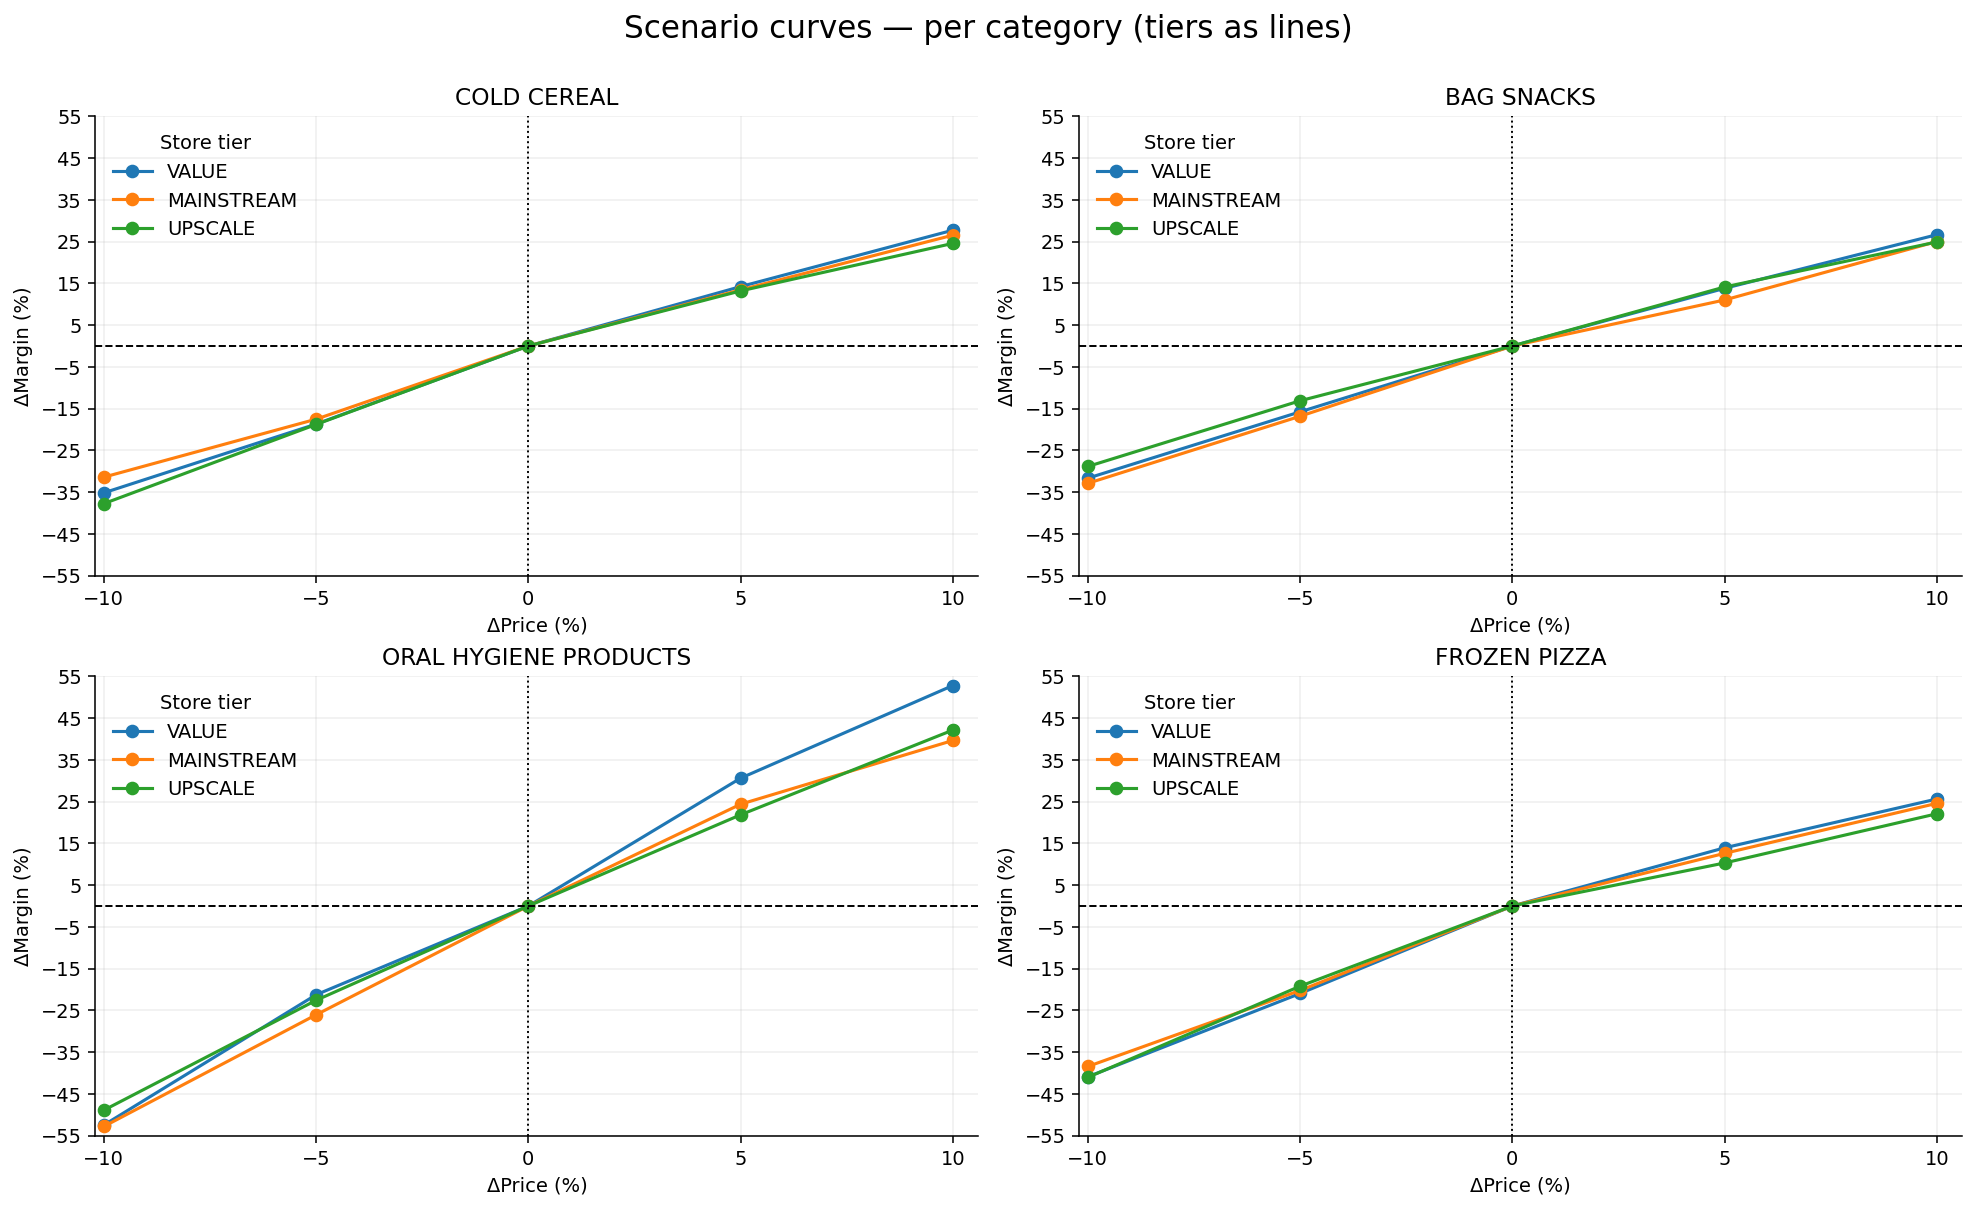

,CATEGORY,STORE_TIER,elasticity_near_0,abs_elasticity_<1?,ΔUnits_% @+10,ΔRevenue_% @+10,ΔMargin_% @+10,N_rows_panel
0,BAG SNACKS,MAINSTREAM,-0.478,True,-6.467,3.047,25.017,15000
1,BAG SNACKS,UPSCALE,-0.496,True,-6.308,2.861,24.912,15000
2,BAG SNACKS,VALUE,-0.226,True,-5.130,4.449,26.655,15000
3,COLD CEREAL,MAINSTREAM,-0.421,True,-6.908,2.392,26.540,15000
4,COLD CEREAL,UPSCALE,-0.562,True,-9.726,-1.994,24.572,15000
5,COLD CEREAL,VALUE,-0.514,True,-7.980,0.758,27.731,15000
6,FROZEN PIZZA,MAINSTREAM,-0.506,True,-10.007,-0.865,24.584,15000
7,FROZEN PIZZA,UPSCALE,-0.780,True,-11.871,-4.434,22.084,15000
8,FROZEN PIZZA,VALUE,-0.553,True,-11.106,-2.606,25.624,15000
9,ORAL HYGIENE PRODUCTS,MAINSTREAM,0.437,True,-6.967,2.518,39.638,15000


✅ All segments in-window are inelastic (|ε|<1).


**Scenario curves — in-window behaviour**
- Within ±10%, **all Category×Tier segments are inelastic** (local |ε| < 1 near ΔPrice≈0).
- Curves are **smooth and near-linear** → no threshold/inflection behaviour in-window.
- Tier lines are **roughly parallel** → **category** drives sensitivity more than **store tier**.

**Next:** Summarise the +10% step: all Category×Tier chart, decision table, and VALUE-tier cut.

In [21]:
## 8A) Scenario curves + In-window elasticity check
# ---------- Ensure scenario panels exist ----------
def build_summary_scenarios(dfX, top_k=4, deltas=(-0.10,-0.05,0.0,+0.05,+0.10), margin_rate=0.30, take_n=3000):
    seg_rows=[]
    if "CATEGORY" not in dfX.columns:
        raise KeyError("dfX must include 'CATEGORY'")
    tiers = dfX["STORE_TIER"].dropna().unique().tolist() if "STORE_TIER" in dfX.columns else [None]
    top_cats = dfX["CATEGORY"].dropna().astype(str).value_counts().head(top_k).index.tolist()
    for c in top_cats:
        for t in tiers:
            filt = {"CATEGORY": c}
            if t is not None: filt["STORE_TIER"] = t
            panel = scenario_grid(filt, deltas=list(deltas), margin_rate=margin_rate, take_n=take_n)
            if not panel.empty:
                panel["CATEGORY"]   = c
                panel["STORE_TIER"] = t
                panel["BEST_BY_MARGIN_IDX"] = panel["ΔMargin_%"].idxmax()
                seg_rows.append(panel)
    return pd.concat(seg_rows, ignore_index=True) if seg_rows else pd.DataFrame()

if "summary_scenarios" not in globals() or summary_scenarios is None or summary_scenarios.empty:
    summary_scenarios = build_summary_scenarios(dfX)

if summary_scenarios.empty:
    raise RuntimeError("summary_scenarios is empty — no segments built for scenario curves.")

# ---------- Scenario curves (facet by category, tiers as lines) ----------
def facet_by_category_uniform(df, outpath=OUTDIR / "fig_scenarios.png"):
    cats = sorted(df["CATEGORY"].dropna().unique().tolist(),
                  key=lambda c: df[df["CATEGORY"]==c]["N_rows"].sum(), reverse=True)
    n = len(cats); cols = 2 if n>2 else n; rows = (n+cols-1)//cols

    x_vals = df["ΔPrice_%"].to_numpy(); y_vals = df["ΔMargin_%"].to_numpy()
    def _rdown(x, step): return step * np.floor(x / step)
    def _rup(x, step):   return step * np.ceil(x  / step)
    x_min, x_max = _rdown(np.nanmin(x_vals), 5), _rup(np.nanmax(x_vals), 5)
    y_min, y_max = _rdown(np.nanmin(y_vals), 5), _rup(np.nanmax(y_vals), 5)
    x_min -= 0.2; x_max += 0.6
    x_ticks = sorted(np.unique(df["ΔPrice_%"])) or np.arange(x_min, x_max+1e-9, 5)
    y_ticks = np.arange(y_min, y_max+1e-9, 10)

    fig, axes = plt.subplots(rows, cols, figsize=(7*cols, 4*rows), constrained_layout=True)
    axes = np.atleast_2d(axes)
    tier_order = [t for t in ["VALUE","MAINSTREAM","UPSCALE"] if t in df["STORE_TIER"].unique()]

    for ax, c in zip(axes.ravel(), cats):
        p = df[df["CATEGORY"].eq(c)].copy()
        for t in [t for t in tier_order if t in set(p["STORE_TIER"])]:
            q = p[p["STORE_TIER"].eq(t)].sort_values("ΔPrice_%")
            if q.empty: continue
            ax.plot(q["ΔPrice_%"], q["ΔMargin_%"], marker="o", label=t, linewidth=1.6)
            best = q.loc[q["ΔMargin_%"].idxmax()]
            ax.scatter([best["ΔPrice_%"]], [best["ΔMargin_%"]], s=32, zorder=4)

        ax.axhline(0, ls="--", lw=1, color="black")
        ax.axvline(0, ls=":",  lw=1, color="black")
        ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
        ax.set_xticks(x_ticks); ax.set_yticks(y_ticks)
        ax.set_title(str(c).upper()); ax.set_xlabel("ΔPrice (%)"); ax.set_ylabel("ΔMargin (%)")
        ax.legend(title="Store tier", loc="upper left", frameon=False); ax.grid(alpha=0.2)

    for ax in axes.ravel()[len(cats):]:
        ax.axis("off")

    fig.suptitle("Scenario curves — per category (tiers as lines)", y=1.06, fontsize=16)
    plt.savefig(outpath, bbox_inches="tight", pad_inches=0.6)
    plt.show()

facet_by_category_uniform(summary_scenarios)

# ---------- In-window elasticity (strict neighbors around 0) ----------
def local_elasticity_from_panel(panel: pd.DataFrame, around=0.0):
    p = (panel.dropna(subset=["ΔPrice_%","ΔUnits_%"]).sort_values("ΔPrice_%"))
    if p.empty: return np.nan
    below = p[p["ΔPrice_%"] < around].iloc[-1:]
    above = p[p["ΔPrice_%"] > around].iloc[:1]
    if below.empty:
        zero = p[p["ΔPrice_%"].round(6).eq(around)].iloc[-1:]
        below = zero
    if above.empty:
        zero = p[p["ΔPrice_%"].round(6).eq(around)].iloc[:1]
        above = zero
    if below.empty or above.empty:
        return np.nan
    dP = float(above["ΔPrice_%"].values[0] - below["ΔPrice_%"].values[0])
    dU = float(above["ΔUnits_%"].values[0] - below["ΔUnits_%"].values[0])
    return np.nan if abs(dP) < 1e-9 else (dU / dP)

def build_inwindow_elasticity_table(summary: pd.DataFrame) -> pd.DataFrame:
    rows=[]
    for (c,t), g in summary.groupby(["CATEGORY","STORE_TIER"]):
        e0 = local_elasticity_from_panel(g, around=0.0)
        at10 = g.loc[g["ΔPrice_%"].sub(10).abs().idxmin()]
        rows.append({
            "CATEGORY": c, "STORE_TIER": t,
            "elasticity_near_0": e0,
            "abs_elasticity_<1?": (abs(e0) < 1.0) if pd.notna(e0) else np.nan,
            "ΔUnits_% @+10":   float(at10["ΔUnits_%"]),
            "ΔRevenue_% @+10": float(at10["ΔRevenue_%"]),
            "ΔMargin_% @+10":  float(at10["ΔMargin_%"]),
            "N_rows_panel":    int(g["N_rows"].sum())
        })
    out = pd.DataFrame(rows).sort_values(["CATEGORY","STORE_TIER"]).reset_index(drop=True)
    out.to_csv(OUTDIR/"scenario_inwindow_elasticity_check.csv", index=False)
    display(out.round(3))
    if out["abs_elasticity_<1?"].dropna().eq(False).any():
        bad = out[out["abs_elasticity_<1?"].eq(False)]
        print("⚠️ Elastic in-window segments:", bad[["CATEGORY","STORE_TIER","elasticity_near_0"]].to_string(index=False))
    else:
        print("✅ All segments in-window are inelastic (|ε|<1).")
    return out

inwin_tbl = build_inwindow_elasticity_table(summary_scenarios)

takeaway(
  "Scenario curves — in-window behaviour",
  [
    "Within ±10%, **all Category×Tier segments are inelastic** (local |ε| < 1 near ΔPrice≈0).",
    "Curves are **smooth and near-linear** → no threshold/inflection behaviour in-window.",
    "Tier lines are **roughly parallel** → **category** drives sensitivity more than **store tier**."
  ],
  nxt="Summarise the +10% step: all Category×Tier chart, decision table, and VALUE-tier cut."
)

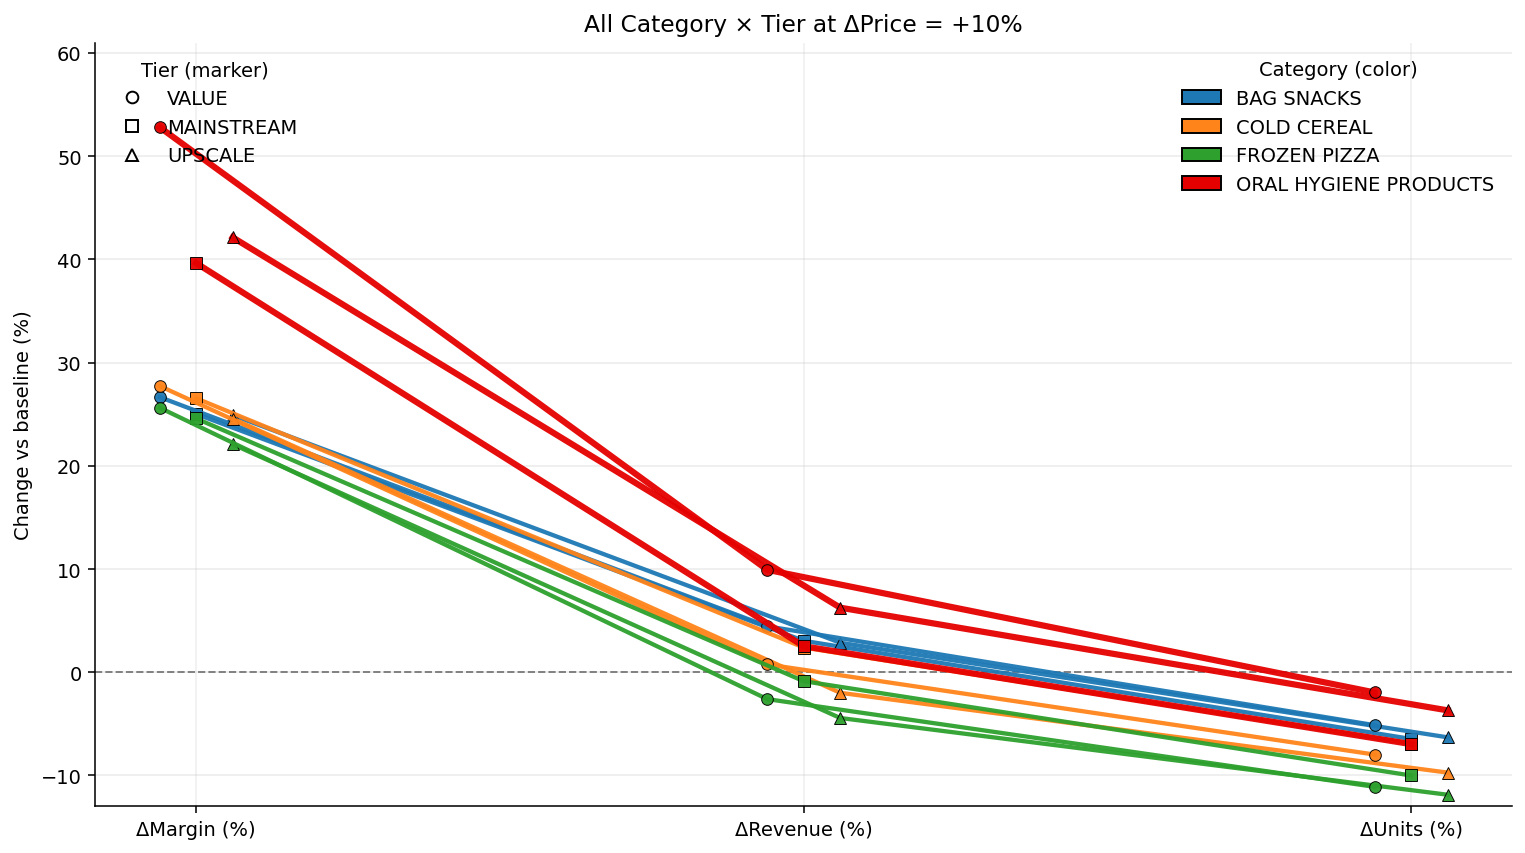

,CATEGORY,STORE_TIER,Rec_ΔPrice_%,Exp_ΔMargin_%,Exp_ΔUnits_%,Exp_ΔRevenue_%,N_rows
0,BAG SNACKS,MAINSTREAM,10%,+25.0%,-6.5%,+3.0%,"3,000.0"
1,BAG SNACKS,UPSCALE,10%,+24.9%,-6.3%,+2.9%,"3,000.0"
2,BAG SNACKS,VALUE,10%,+26.7%,-5.1%,+4.4%,"3,000.0"
3,COLD CEREAL,MAINSTREAM,10%,+26.5%,-6.9%,+2.4%,"3,000.0"
4,COLD CEREAL,UPSCALE,10%,+24.6%,-9.7%,-2.0%,"3,000.0"
5,COLD CEREAL,VALUE,10%,+27.7%,-8.0%,+0.8%,"3,000.0"
6,FROZEN PIZZA,MAINSTREAM,10%,+24.6%,-10.0%,-0.9%,"3,000.0"
7,FROZEN PIZZA,UPSCALE,10%,+22.1%,-11.9%,-4.4%,"3,000.0"
8,FROZEN PIZZA,VALUE,10%,+25.6%,-11.1%,-2.6%,"3,000.0"
9,ORAL HYGIENE PRODUCTS,MAINSTREAM,10%,+39.6%,-7.0%,+2.5%,"3,000.0"


**ΔPrice = +10% — summary exhibits**
- Across Category×Tier, **margin expands ~+25–53%**; ordering is **Oral Hygiene** (highest) → **Cereal/Snacks** → **Frozen Pizza**.
- **Units soften ~−2% to −11%**, consistent with the **inelastic** regime.
- **Revenue** is net ↑ for **Snacks**, **Cereal**, **Oral Hygiene**; **Frozen Pizza** is slightly ↓ — add feature/display support where volume is most sensitive.
- Tier effects are **small** (near-parallel markers), so the **decision table** prioritises **category** over tier customisation.

**Next:** For a simpler view, show the VALUE-tier poster cut; export VALUE-only decision table.

In [22]:
## 8B) +10% Exhibits — All cat×tier graph, Decision table
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.legend import Legend

# ---------- Helpers (accept Δ*_% or Delta*_% headers) ----------
def _normalize_delta_cols(df):
    col_map = {
        "DeltaPrice_%":  ["DeltaPrice_%","ΔPrice_%"],
        "DeltaMargin_%": ["DeltaMargin_%","ΔMargin_%"],
        "DeltaRevenue_%":["DeltaRevenue_%","ΔRevenue_%"],
        "DeltaUnits_%":  ["DeltaUnits_%","ΔUnits_%"],
        "N_rows":        ["N_rows","N_rows_panel","N"]
    }
    d = df.copy()
    for std, alts in col_map.items():
        if std not in d.columns:
            for a in alts:
                if a in d.columns:
                    d = d.rename(columns={a: std}); break
    return d

# Build KPI table at +10 if missing
def kpis_for_all_segments_at_delta(dfX, delta_pct=+10.0, margin_rate=0.30, take_n=3000):
    rows=[]; tiers = dfX["STORE_TIER"].dropna().unique().tolist() if "STORE_TIER" in dfX.columns else [None]
    for c in sorted(dfX["CATEGORY"].dropna().astype(str).unique()):
        for t in (sorted([str(x) for x in tiers]) if tiers != [None] else [None]):
            seg = {"CATEGORY": c}; 
            if t is not None: seg["STORE_TIER"] = t
            panel = scenario_grid(seg, deltas=[delta_pct/100.0], margin_rate=margin_rate, take_n=take_n)
            if panel is None or panel.empty: continue
            r = panel.iloc[0].to_dict()
            r.update({"CATEGORY": c, "STORE_TIER": t if t is not None else "ALL"})
            rows.append(r)
    return pd.DataFrame(rows)

if "kpi_all" not in globals() or kpi_all is None or kpi_all.empty:
    kpi_all = kpis_for_all_segments_at_delta(dfX, delta_pct=+10.0, margin_rate=0.30, take_n=3000)

kpi_all = _normalize_delta_cols(kpi_all)

# ---------- All Category × Tier at ΔPrice = +10% ----------
def plot_all_segments_one_graph_v2(kpi_df,
                                   title=None,
                                   highlight_top_margin=3,
                                   annotate=True,
                                   jitter_by_tier=True,
                                   cat_palette=None):
    df = _normalize_delta_cols(kpi_df)
    if df.empty: raise ValueError("kpi_df is empty.")
    metrics = ["DeltaMargin_%","DeltaRevenue_%","DeltaUnits_%"]; x = np.arange(len(metrics))

    cats  = sorted(df["CATEGORY"].astype(str).unique().tolist())
    poster_order = ["BAG SNACKS","COLD CEREAL","FROZEN PIZZA","ORAL HYGIENE PRODUCTS"]
    cats = [c for c in poster_order if c in cats] + [c for c in cats if c not in poster_order]
    tiers = [t for t in ["VALUE","MAINSTREAM","UPSCALE"] if t in df["STORE_TIER"].unique()] \
            or sorted(df["STORE_TIER"].astype(str).unique().tolist())

    if cat_palette is None:
        base = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#D55E00", "#56B4E9"]
    else:
        base = list(cat_palette); 
        if len(base) < len(cats):
            reps = (len(cats) + len(base) - 1) // len(base); base = (base*reps)[:len(cats)]
    cat_colors = {c: col for c, col in zip(cats, base)}
    tier_mark  = {t:m for t,m in zip(tiers, ["o","s","^","D","P"])}

    N = pd.to_numeric(df["N_rows"], errors="coerce").to_numpy()
    nmin, nmax = (np.nanmin(N) if np.isfinite(N).any() else 1.0,
                  np.nanmax(N) if np.isfinite(N).any() else 1.0)
    def lw(n):
        if not np.isfinite(n) or nmax==nmin: return 2.2
        t = (n - nmin)/(nmax - nmin); return 1.2 + 2.3*float(np.clip(t,0,1))

    t_idx = {t:i for i,t in enumerate(tiers)}
    def xpos(base, tier):
        if not jitter_by_tier: return base
        return base + (t_idx[tier] - (len(tiers)-1)/2.0)*0.06

    df = df.sort_values("N_rows")
    fig, ax = plt.subplots(figsize=(11, 6.2))
    ax.axhline(0, ls="--", lw=1, color="0.5"); ax.grid(axis="y", alpha=0.25)
    ymin = min(np.nanmin(df[metrics].to_numpy()), -12) - 1
    ymax = max(np.nanmax(df[metrics].to_numpy()),  60) + 1
    ax.set_ylim(ymin, ymax)

    lines_meta=[]
    for _, row in df.iterrows():
        cat, tier = str(row["CATEGORY"]), str(row["STORE_TIER"])
        ys = [row[m] for m in metrics]; xs = [xpos(i, tier) for i in x]
        line = ax.plot(xs, ys, lw=lw(row["N_rows"]), color="0.75",
                       marker=tier_mark.get(tier,"o"), markersize=6,
                       markeredgecolor="black", markeredgewidth=0.5, zorder=2)[0]
        lines_meta.append((line, cat, tier, xs, ys, row["N_rows"]))

    top_pairs = (df.sort_values("DeltaMargin_%", ascending=False)
                   .head(highlight_top_margin)[["CATEGORY","STORE_TIER"]]
                   .astype(str).agg(" · ".join, axis=1).tolist())
    for line, cat, tier, xs, ys, n in lines_meta:
        line.set_color(cat_colors[cat]); line.set_alpha(0.95)
        if f"{cat} · {tier}" in top_pairs:
            line.set_linewidth(max(line.get_linewidth(), 3.2)); line.set_zorder(3)

    if annotate:
        def show(v, metric):
            th = {"DeltaMargin_%":2.0, "DeltaRevenue_%":1.5, "DeltaUnits_%":2.5}[metric]
            return np.isfinite(v) and abs(v) >= th
        for _, row in df.iterrows():
            cat, tier = str(row["CATEGORY"]), str(row["STORE_TIER"])
            xs = [xpos(i, tier) for i in x]
            for xi, metric in zip(xs, metrics):
                v = float(row[metric])
                if show(v, metric):
                    ax.text(xi, v + (0.7 if v>=0 else -0.7), f"{v:+.1f}%",
                            ha="center", va=("bottom" if v>=0 else "top"),
                            fontsize=8, color=cat_colors[cat], zorder=4)

    ax.set_xticks(x); ax.set_xticklabels(["ΔMargin (%)","ΔRevenue (%)","ΔUnits (%)"])
    ax.set_ylabel("Change vs baseline (%)")
    if title is None:
        dp = df["DeltaPrice_%"].iloc[0] if "DeltaPrice_%" in df.columns else np.nan
        title = f"All Category × Tier at ΔPrice = {dp:+.0f}%"
    ax.set_title(title)

    tier_handles = [Line2D([0],[0], marker=tier_mark[t], ls="", markeredgecolor="black",
                           markerfacecolor="white", label=t) for t in tiers]
    cat_handles  = [Patch(facecolor=cat_colors[c], edgecolor="black", label=c) for c in cats]
    leg1 = ax.legend(handles=tier_handles, title="Tier (marker)", frameon=False, loc="upper left")
    ax.add_artist(leg1)
    ax.legend(handles=cat_handles, title="Category (color)", frameon=False, loc="upper right")
    fig.tight_layout()
    return fig, ax

brand = ["#1D78B4", "#FF841A", "#2DA02D", "#E50000"]
fig, ax = plot_all_segments_one_graph_v2(kpi_all, annotate=False, cat_palette=brand)
savefig(OUTDIR / "fig_all_segments_delta10.png")

# ---------- Decision table (best ΔMargin%; fallback to baseline if negative) ----------
ss = summary_scenarios.copy()
ss = _normalize_delta_cols(ss).rename(columns={
    "DeltaPrice_%":"ΔPrice_%","DeltaMargin_%":"ΔMargin_%",
    "DeltaUnits_%":"ΔUnits_%","DeltaRevenue_%":"ΔRevenue_%"
})
need_cols = ["CATEGORY","STORE_TIER","ΔPrice_%","ΔMargin_%","ΔUnits_%","ΔRevenue_%","N_rows"]
best_idx = ss.groupby(["CATEGORY","STORE_TIER"])["ΔMargin_%"].idxmax()
rec = ss.loc[best_idx, need_cols].reset_index(drop=True)

def _traffic(v):
    if pd.isna(v): return "background-color:#f5f5f5"
    if v > 0:      return "background-color:#e8f5e9"
    if v < 0:      return "background-color:#fdecea"
    return "background-color:#f7f7f7"

baseline = ss[ss["ΔPrice_%"].eq(0)].set_index(["CATEGORY","STORE_TIER"])
def _fallback(row):
    key = (row["CATEGORY"], row["STORE_TIER"])
    if row["ΔMargin_%"] < 0 and key in baseline.index:
        base = baseline.loc[key]
        if isinstance(base, pd.DataFrame): base = base.iloc[0]
        for c in ["ΔPrice_%","ΔMargin_%","ΔUnits_%","ΔRevenue_%","N_rows"]:
            row[c] = float(base[c]) if c != "N_rows" else int(base[c])
    return row

rec = rec.apply(_fallback, axis=1)
decision = (
    rec.rename(columns={
        "ΔPrice_%":"Rec_ΔPrice_%",
        "ΔMargin_%":"Exp_ΔMargin_%",
        "ΔUnits_%":"Exp_ΔUnits_%",
        "ΔRevenue_%":"Exp_ΔRevenue_%"
    })
    .sort_values(["CATEGORY","STORE_TIER"])
    .reset_index(drop=True)
)
display(
    decision.style
            .applymap(_traffic, subset=["Exp_ΔMargin_%","Exp_ΔUnits_%","Exp_ΔRevenue_%"])
    .format({
        "Rec_ΔPrice_%":"{:.0f}%",
        "Exp_ΔMargin_%":"{:+.1f}%",
        "Exp_ΔUnits_%":"{:+.1f}%",
        "Exp_ΔRevenue_%":"{:+.1f}%",
        "N_rows":"{:,}"
    })
    .set_properties(subset=["CATEGORY","STORE_TIER"], **{"font-weight":"bold"})
)
decision.to_csv(OUTDIR / "decision_table_all_tiers.csv", index=False)

takeaway(
  "ΔPrice = +10% — summary exhibits",
  [
    "Across Category×Tier, **margin expands ~+25–53%**; ordering is **Oral Hygiene** (highest) → **Cereal/Snacks** → **Frozen Pizza**.",
    "**Units soften ~−2% to −11%**, consistent with the **inelastic** regime.",
    "**Revenue** is net ↑ for **Snacks**, **Cereal**, **Oral Hygiene**; **Frozen Pizza** is slightly ↓ — add feature/display support where volume is most sensitive.",
    "Tier effects are **small** (near-parallel markers), so the **decision table** prioritises **category** over tier customisation."
  ],
  nxt="For a simpler view, show the VALUE-tier poster cut; export VALUE-only decision table."
)

In [23]:
## Executive Summary
## 9) Executive Snapshot + Final Discussion
k_pen = weekly_biz["PROMO_PENETRATION_%"].dropna()
k_dep = weekly_biz["PROMO_DEPTH_%"].dropna()
k_rev = weekly_rev["PROMO_REV_SHARE_%_R4"].dropna()

msg = f"""
### Executive snapshot
- **Promo penetration (units on promo)**: latest **{k_pen.iloc[-1]:.1f}%**, 8w avg **{k_pen.tail(8).mean():.1f}%**
- **Promo depth (avg discount on promo)**: latest **{k_dep.iloc[-1]:.1f}%**, 8w avg **{k_dep.tail(8).mean():.1f}%**
- **Promo share of revenue (R4)**: latest **{k_rev.iloc[-1]:.1f}%**

**Elasticities (point estimates + robustness)**
- Market β_all **{beta_market:.2f}**, off-promo β_off **{off_e:.2f}** (UPC/Store/Week FE with promo controls).
- Heterogeneity: **Category >> Tier** (see `segment_elasticities.csv`).
- Stability: rolling-origin summary in `elasticity_stability_rolling.csv` (mean, std, min–max, sign flips).

**Model (XGB)**
- MAE **{metrics_df['MAE'].iloc[0]:.2f}**, RMSE **{metrics_df['RMSE'].iloc[0]:.2f}**, WAPE **{metrics_df['WAPE_%'].iloc[0]:.1f}%**
- R² (units) **{metrics_df['R2_test_units'].iloc[0]:.3f}**, R² (log1p) **{metrics_df['R2_test_log1p'].iloc[0]:.3f}**
- Robustness: leak-safe features; calibrated; outperforms naïve baselines.

**So what:** Within the operational window (±10%), demand is **inelastic**. Use **+5–10% list moves** to lift margin; support volume in sensitive foods (**Frozen Pizza**) with **feature/display**, not deep TPR-only.
"""
display(Markdown(msg))

display(Markdown("""
### Final discussion — scientific impact & market context

**Scientific impact.** We pair **fixed-effects OLS** (interpretable β) with an **XGB forecaster** (operational accuracy). The pipeline is **leak-safe** and pre-aggregates duplicates. Robustness leans on **rolling-origin stability**, **holdout/CV**, and **in-window scenario checks**.

**Market context.** Across tiers, **penetration** explains revenue swings more than **depth** → favour **lighter, more frequent** incentives with visibility. **Within ±10% all categories are inelastic.** Operationally: protect base price in inelastic **care**; use calibrated shallow promos in **foods**, with feature/display.

**Limitations & next steps.** Elasticities are directional (promo timing, omitted shocks). Next: IVs or off-promo identification; joint demand (cannibalization/halo); SKU-level costs in margins; validate with geo-tests.

**Bottom line.** Evidence supports a **lighter–deeper trade-off**: widen promo **penetration** with **shallower cuts**; **protect base** in inelastic care; avoid tier over-customization. Use the decision table to plan next-cycle moves and vendor negotiations.
"""))


### Executive snapshot
- **Promo penetration (units on promo)**: latest **52.1%**, 8w avg **43.9%**
- **Promo depth (avg discount on promo)**: latest **19.6%**, 8w avg **22.5%**
- **Promo share of revenue (R4)**: latest **33.4%**

**Elasticities (point estimates + robustness)**
- Market β_all **-1.38**, off-promo β_off **-1.34** (UPC/Store/Week FE with promo controls).
- Heterogeneity: **Category >> Tier** (see `segment_elasticities.csv`).
- Stability: rolling-origin summary in `elasticity_stability_rolling.csv` (mean, std, min–max, sign flips).

**Model (XGB)**
- MAE **5.31**, RMSE **10.79**, WAPE **28.4%**
- R² (units) **0.843**, R² (log1p) **0.825**
- Robustness: leak-safe features; calibrated; outperforms naïve baselines.

**So what:** Within the operational window (±10%), demand is **inelastic**. Use **+5–10% list moves** to lift margin; support volume in sensitive foods (**Frozen Pizza**) with **feature/display**, not deep TPR-only.



### Final discussion — scientific impact & market context

**Scientific impact.** We pair **fixed-effects OLS** (interpretable β) with an **XGB forecaster** (operational accuracy). The pipeline is **leak-safe** and pre-aggregates duplicates. Robustness leans on **rolling-origin stability**, **holdout/CV**, and **in-window scenario checks**.

**Market context.** Across tiers, **penetration** explains revenue swings more than **depth** → favour **lighter, more frequent** incentives with visibility. **Within ±10% all categories are inelastic.** Operationally: protect base price in inelastic **care**; use calibrated shallow promos in **foods**, with feature/display.

**Limitations & next steps.** Elasticities are directional (promo timing, omitted shocks). Next: IVs or off-promo identification; joint demand (cannibalization/halo); SKU-level costs in margins; validate with geo-tests.

**Bottom line.** Evidence supports a **lighter–deeper trade-off**: widen promo **penetration** with **shallower cuts**; **protect base** in inelastic care; avoid tier over-customization. Use the decision table to plan next-cycle moves and vendor negotiations.
